# Network Congestion Prediction — Feature Engineering Notebook

**Dataset:** `congestion_training.csv` — 105,982 rows × 57 columns  
**Task:** Multi-class congestion classification (labels 0–4) with temporal feature engineering  
**Key findings pre-notebook:**
- `t` is a simulation timestamp (seconds), irregular sub-second steps, one panel per node
- 6 nodes: `boundary` (majority, 84 K rows), `core0–2`, `edge0–1`
- Two scenarios: `training_congestion` (77 K) and `training_portscan` (28 K)
- Port-scan rows look statistically similar to congestion rows → **treat as anomaly context, not exclude**
- `tcp_synack` is constant zero → **drop**
- `active_flows` is near-binary (0/1) → low signal as continuous
- Pre-engineered composite cols (`traffic_intensity`, `queue_stress`, `iat_pressure`, etc.) are **not** identical to raw cols but derived from them → **leakage risk: keep for EDA but exclude from model features**
- Target: `congestion_label` ∈ {0, 1, 2, 4} (imbalanced: label 2 dominates)

## 1. Imports & Setup

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (14, 4)

FILE_ID = '1uNd8iiTHT9Xp_aeMeKJ4ie-aQZIS64VD'  # adjust path if needed

## 2. Load & Initial Inspection

In [51]:
df = pd.read_csv(f'https://drive.google.com/uc?id={FILE_ID}')
print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
df.head(3)

Shape: (105982, 57)
Columns (57): ['t', 'node_id', 'scenario', 'bw_in_mbps', 'bw_out_mbps', 'bw_avg_mbps', 'util_in_pct', 'util_out_pct', 'pkt_in', 'pkt_out', 'pkt_dropped', 'pkt_loss_pct', 'bytes_in', 'bytes_out', 'payload_bytes', 'total_bytes', 'jitter_ms', 'iat_mean_ms', 'rtt_avg_ms', 'rtt_std_ms', 'ospf_pkts', 'arp_pkts', 'icmp_pkts', 'udp_pkts', 'tcp_pkts', 'udp_fraction', 'tcp_fraction', 'proto_overhead_pct', 'ospf_overhead_pct', 'tcp_ctrl_pct', 'tcp_syn', 'tcp_synack', 'tcp_fin', 'tcp_rst', 'tcp_retransmit_pct', 'syn_rate_pps', 'rst_rate_pps', 'fin_rate_pps', 'active_flows', 'new_flows', 'finished_flows', 'flow_churn_per_sec', 'peak_kbps_1s_window', 'pkt_asymmetry', 'bw_asymmetry', 'flow_density', 'ctrl_to_data_ratio', 'bytes_per_pkt_out', 'syn_rst_ratio_router', 'tcp_health_score', 'traffic_intensity', 'iat_pressure', 'queue_stress', 'bw_util_ratio', 'drop_rate_trend', 'ctrl_pkt_ratio', 'congestion_label']


,t,node_id,scenario,bw_in_mbps,bw_out_mbps,bw_avg_mbps,util_in_pct,util_out_pct,pkt_in,pkt_out,...,bytes_per_pkt_out,syn_rst_ratio_router,tcp_health_score,traffic_intensity,iat_pressure,queue_stress,bw_util_ratio,drop_rate_trend,ctrl_pkt_ratio,congestion_label
0,10.0,boundary,training_congestion,0.014318,0.008203,0.011261,0.000143,0.000082,149,80,...,128.175000,0.0,1.0,0.011261,13.374454,0.0,0.572915,0.0,0.336245,0
1,10.0,core0,training_congestion,0.016040,0.007440,0.011740,0.000160,0.000074,165,79,...,117.721519,0.0,1.0,0.011740,13.204353,0.0,0.463840,0.0,0.311475,0
2,10.0,core1,training_congestion,0.015554,0.015827,0.015690,0.000156,0.000158,183,135,...,146.548148,0.0,1.0,0.015690,22.663195,0.0,1.017552,0.0,0.408805,0


In [52]:
print('=== dtypes ===')
print(df.dtypes.to_string())
print('\n=== Missing values ===')
miss = df.isnull().sum()
print(miss[miss > 0] if miss.any() else 'None — dataset is complete')
print('\n=== Target distribution ===')
print(df['congestion_label'].value_counts().sort_index())

=== dtypes ===
t                       float64
node_id                     str
scenario                    str
bw_in_mbps              float64
bw_out_mbps             float64
bw_avg_mbps             float64
util_in_pct             float64
util_out_pct            float64
pkt_in                    int64
pkt_out                   int64
pkt_dropped               int64
pkt_loss_pct            float64
bytes_in                  int64
bytes_out                 int64
payload_bytes             int64
total_bytes               int64
jitter_ms               float64
iat_mean_ms             float64
rtt_avg_ms              float64
rtt_std_ms              float64
ospf_pkts                 int64
arp_pkts                  int64
icmp_pkts                 int64
udp_pkts                  int64
tcp_pkts                  int64
udp_fraction            float64
tcp_fraction            float64
proto_overhead_pct      float64
ospf_overhead_pct       float64
tcp_ctrl_pct            float64
tcp_syn                  

In [53]:
# Scenario vs label cross-tab
print('=== Scenario × Congestion Label ===')
print(pd.crosstab(df['scenario'], df['congestion_label'], margins=True))

print('\n=== Node counts ===')
print(df['node_id'].value_counts())

=== Scenario × Congestion Label ===
congestion_label         0      1      2     4     All
scenario                                              
training_congestion  16110   6946  47838  6878   77772
training_portscan     5571   3322  17688  1629   28210
All                  21681  10268  65526  8507  105982

=== Node counts ===
node_id
boundary    84607
core0        4275
core1        4275
core2        4275
edge0        4275
edge1        4275
Name: count, dtype: int64


## 3. Preprocessing & Cleanup

In [55]:
# ── 3.1 Drop constant & near-useless columns ──────────────────────────────
DROP_CONSTANT = ['tcp_synack']  # constant zero in entire dataset

# ── 3.2 Pre-engineered composite columns → LEAKAGE RISK ──────────────────
# These are derived features computed at simulation time from raw signals.
# They are NOT available as true future inputs → exclude from model features.
# Keep for EDA only.
COMPOSITE_LEAKAGE = [
    'traffic_intensity',  # derived from bw_avg_mbps
    'iat_pressure',       # derived from iat_mean_ms
    'queue_stress',       # derived from pkt_loss + queue signals
    'bw_util_ratio',      # derived from bw + util
    'drop_rate_trend',    # derived from pkt_dropped
    'ctrl_pkt_ratio',     # derived from ctrl/data ratio
]

# ── 3.3 Port-scan scenario: tag as anomaly context, don't hard-exclude ────
# Port-scan rows have similar label distributions to congestion rows.
# We encode scenario as a binary feature instead of dropping.
df['is_portscan'] = (df['scenario'] == 'training_portscan').astype(int)

# ── 3.4 Drop unused metadata columns ─────────────────────────────────────
DROP_META = ['scenario']  # encoded above

all_drop = DROP_CONSTANT + DROP_META
df.drop(columns=all_drop, inplace=True)
print(f'Dropped: {all_drop}')
print(f'Remaining columns: {df.shape[1]}')

KeyError: 'scenario'

In [56]:
# ── 3.5 Encode node_id ────────────────────────────────────────────────────
le_node = LabelEncoder()
df['node_id_enc'] = le_node.fit_transform(df['node_id'])
print('Node encoding:', dict(zip(le_node.classes_, le_node.transform(le_node.classes_))))

Node encoding: {'boundary': np.int64(0), 'core0': np.int64(1), 'core1': np.int64(2), 'core2': np.int64(3), 'edge0': np.int64(4), 'edge1': np.int64(5)}


In [57]:
# ── 3.6 Sort by node + timestamp ─────────────────────────────────────────
df.sort_values(['node_id', 't'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Timestamp gap per node
df['t_diff'] = df.groupby('node_id')['t'].diff().fillna(0)
print('Median time-step per node (seconds):')
print(df.groupby('node_id')['t_diff'].median())

Median time-step per node (seconds):
node_id
boundary    0.57
core0       0.52
core1       0.53
core2       0.54
edge0       0.52
edge1       0.53
Name: t_diff, dtype: float64


## 4. Exploratory Visualizations

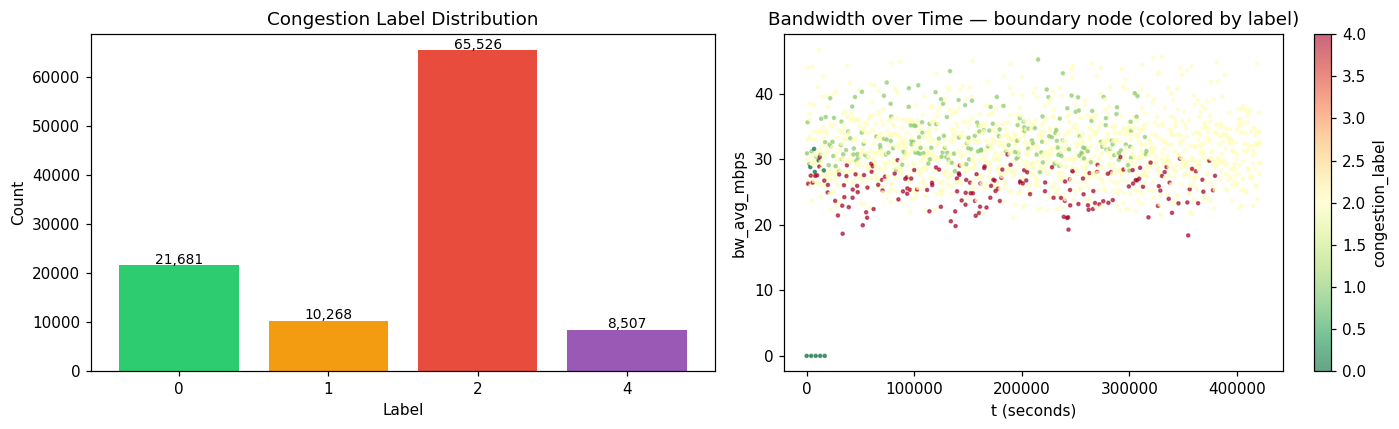

In [58]:
# ── 4.1 Target distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vc = df['congestion_label'].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=['#2ecc71','#f39c12','#e74c3c','#9b59b6'])
axes[0].set_title('Congestion Label Distribution')
axes[0].set_xlabel('Label'); axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=9)

# Bandwidth over time (boundary node)
bnd = df[df['node_id'] == 'boundary'].sort_values('t').copy()
sample = bnd.iloc[::50]  # downsample for plot
sc = axes[1].scatter(sample['t'], sample['bw_avg_mbps'], c=sample['congestion_label'],
                     cmap='RdYlGn_r', s=4, alpha=0.6)
plt.colorbar(sc, ax=axes[1], label='congestion_label')
axes[1].set_title('Bandwidth over Time — boundary node (colored by label)')
axes[1].set_xlabel('t (seconds)'); axes[1].set_ylabel('bw_avg_mbps')
plt.tight_layout(); plt.show()

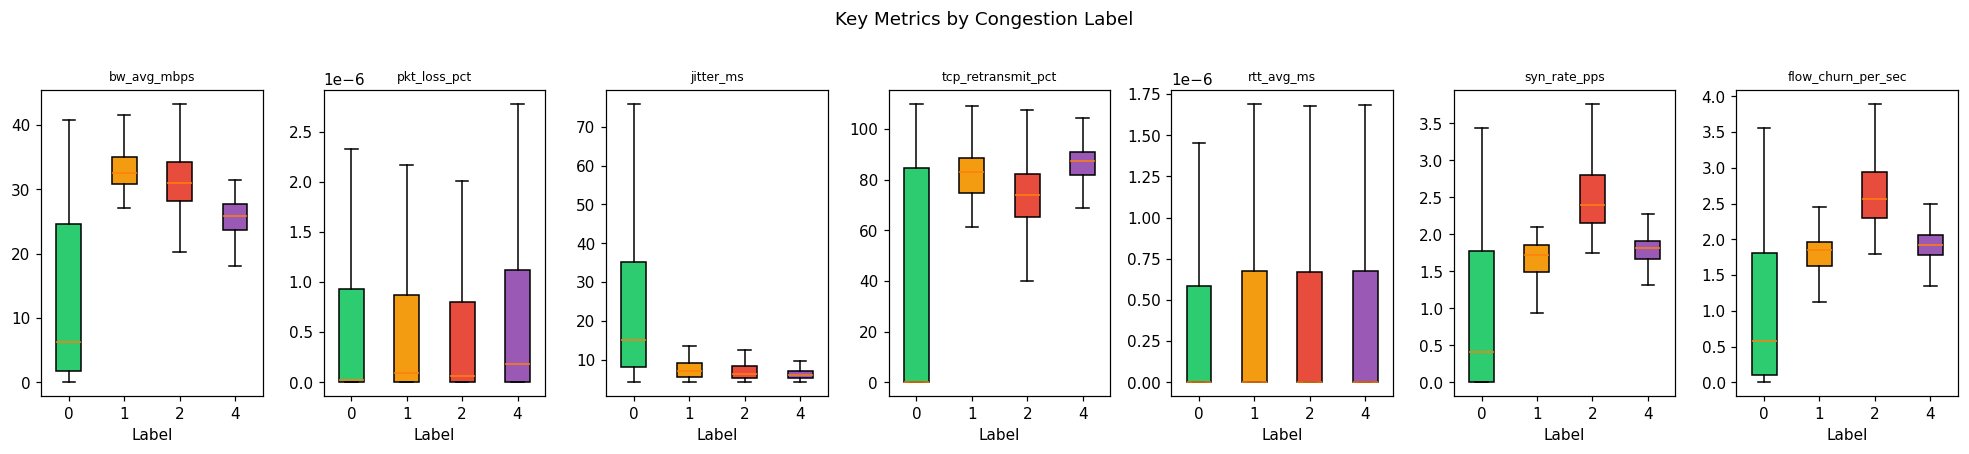

In [59]:
# ── 4.2 Key metrics by label ──────────────────────────────────────────────
metrics = ['bw_avg_mbps', 'pkt_loss_pct', 'jitter_ms', 'tcp_retransmit_pct',
           'rtt_avg_ms', 'syn_rate_pps', 'flow_churn_per_sec']

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))
colors = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c', 4: '#9b59b6'}

for ax, m in zip(axes, metrics):
    grouped = [df[df['congestion_label'] == lbl][m].values for lbl in [0, 1, 2, 4]]
    bp = ax.boxplot(grouped, labels=['0','1','2','4'],
                    patch_artist=True, showfliers=False)
    for patch, lbl in zip(bp['boxes'], [0, 1, 2, 4]):
        patch.set_facecolor(colors[lbl])
    ax.set_title(m, fontsize=8); ax.set_xlabel('Label')

plt.suptitle('Key Metrics by Congestion Label', y=1.02)
plt.tight_layout(); plt.show()

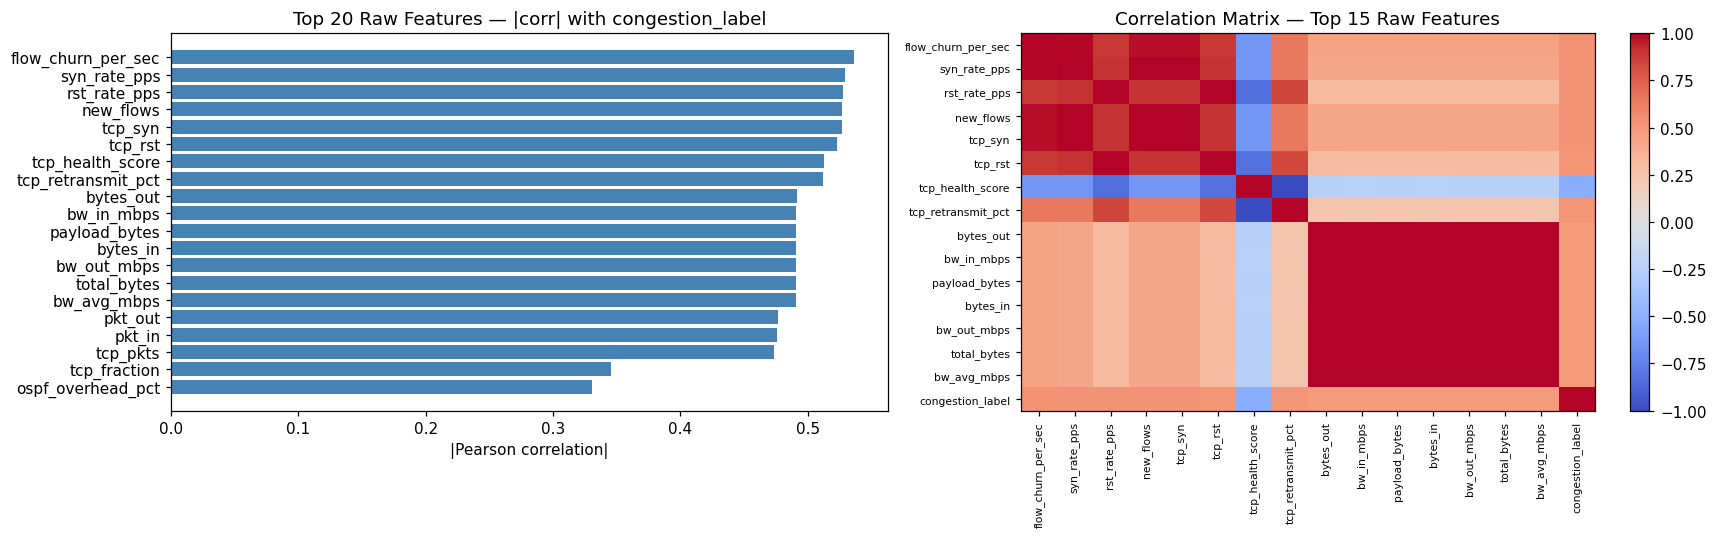

In [8]:
# ── 4.3 Correlation heatmap (raw features) ────────────────────────────────
raw_num_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in COMPOSITE_LEAKAGE + ['congestion_label', 't', 'node_id_enc',
                                                   'is_portscan', 't_diff']]

corr = df[raw_num_cols + ['congestion_label']].corr()
target_corr = corr['congestion_label'].drop('congestion_label').abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top-20 correlations with target
top20 = target_corr.head(20)
axes[0].barh(top20.index[::-1], top20.values[::-1], color='steelblue')
axes[0].set_title('Top 20 Raw Features — |corr| with congestion_label')
axes[0].set_xlabel('|Pearson correlation|')

# Mini heatmap of top-15 features
top15 = list(top20.head(15).index) + ['congestion_label']
mini_corr = df[top15].corr()
im = axes[1].imshow(mini_corr, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(top15))); axes[1].set_xticklabels(top15, rotation=90, fontsize=7)
axes[1].set_yticks(range(len(top15))); axes[1].set_yticklabels(top15, fontsize=7)
plt.colorbar(im, ax=axes[1])
axes[1].set_title('Correlation Matrix — Top 15 Raw Features')

plt.tight_layout(); plt.show()

## 5. Feature Engineering

All lag/rolling features are computed **per node** to avoid cross-node contamination.

In [9]:
# ── Core signals for feature engineering ─────────────────────────────────
# These are the raw, non-leaking, highest-signal columns
CORE_SIGNALS = [
    'bw_avg_mbps', 'bw_in_mbps', 'bw_out_mbps',
    'util_in_pct', 'util_out_pct',
    'pkt_loss_pct', 'pkt_dropped',
    'jitter_ms', 'rtt_avg_ms', 'rtt_std_ms',
    'tcp_retransmit_pct', 'syn_rate_pps', 'rst_rate_pps',
    'flow_churn_per_sec', 'new_flows',
    'peak_kbps_1s_window',
]

# Window sizes (in number of observations per node)
# Median step ~0.5–0.6s → W=5 ≈ 3s, W=10 ≈ 6s, W=30 ≈ 18s
WINDOWS = [5, 10, 30]
LAGS = [1, 3, 5, 10]

fe = df.copy()

In [10]:
# ── 5.1 Lag features ─────────────────────────────────────────────────────
for sig in ['bw_avg_mbps', 'pkt_loss_pct', 'jitter_ms', 'tcp_retransmit_pct', 'syn_rate_pps']:
    for lag in LAGS:
        fe[f'{sig}_lag{lag}'] = fe.groupby('node_id')[sig].shift(lag)

print('Lag features added.')

Lag features added.


In [11]:
# ── 5.2 Rolling statistics (mean, std, max) per node ─────────────────────
for sig in ['bw_avg_mbps', 'pkt_loss_pct', 'jitter_ms', 'tcp_retransmit_pct',
            'flow_churn_per_sec', 'peak_kbps_1s_window']:
    grp = fe.groupby('node_id')[sig]
    for w in WINDOWS:
        fe[f'{sig}_roll_mean_{w}'] = grp.transform(lambda x: x.rolling(w, min_periods=2).mean())
        fe[f'{sig}_roll_std_{w}']  = grp.transform(lambda x: x.rolling(w, min_periods=2).std())

# Rolling max for burst detection
for sig in ['bw_avg_mbps', 'syn_rate_pps', 'pkt_dropped']:
    grp = fe.groupby('node_id')[sig]
    for w in [5, 10]:
        fe[f'{sig}_roll_max_{w}'] = grp.transform(lambda x: x.rolling(w, min_periods=2).max())

print('Rolling stats added.')

Rolling stats added.


In [12]:
# ── 5.3 Rate-of-change features ──────────────────────────────────────────
for sig in ['bw_avg_mbps', 'pkt_loss_pct', 'jitter_ms', 'util_in_pct', 'util_out_pct']:
    grp = fe.groupby('node_id')[sig]
    fe[f'{sig}_delta1']  = grp.diff(1)                          # 1-step change
    fe[f'{sig}_delta5']  = grp.diff(5)                          # 5-step change
    fe[f'{sig}_pct_chg'] = grp.pct_change(fill_method=None)     # % change

print('Rate-of-change features added.')

Rate-of-change features added.


In [13]:
# ── 5.4 Traffic volatility (rolling coeff of variation) ──────────────────
for sig in ['bw_avg_mbps', 'pkt_loss_pct']:
    for w in [10, 30]:
        mu  = fe.groupby('node_id')[sig].transform(lambda x: x.rolling(w, min_periods=3).mean())
        std = fe.groupby('node_id')[sig].transform(lambda x: x.rolling(w, min_periods=3).std())
        fe[f'{sig}_cv_{w}'] = (std / (mu.abs() + 1e-9)).clip(upper=10)

print('Volatility (CV) features added.')

Volatility (CV) features added.


In [14]:
# ── 5.5 Burst indicators ─────────────────────────────────────────────────
# Burst: current value > rolling mean by threshold
for sig in ['bw_avg_mbps', 'syn_rate_pps', 'flow_churn_per_sec']:
    roll_mean = fe.groupby('node_id')[sig].transform(
        lambda x: x.rolling(10, min_periods=3).mean()
    )
    fe[f'{sig}_burst'] = ((fe[sig] - roll_mean) / (roll_mean.abs() + 1e-9)).clip(lower=0)

# SYN flood indicator
fe['syn_flood_indicator'] = (fe['syn_rate_pps'] > fe['syn_rate_pps'].quantile(0.90)).astype(int)

print('Burst indicators added.')

Burst indicators added.


In [15]:
# ── 5.6 Utilization & load ratio features ────────────────────────────────
fe['util_imbalance']    = (fe['util_in_pct'] - fe['util_out_pct']).abs()
fe['util_max']          = fe[['util_in_pct', 'util_out_pct']].max(axis=1)
fe['bw_asym_abs']       = fe['bw_asymmetry'].abs()
fe['loss_per_mbps']     = fe['pkt_loss_pct'] / (fe['bw_avg_mbps'] + 1e-9)   # loss normalized by load
fe['retransmit_load']   = fe['tcp_retransmit_pct'] * fe['bw_avg_mbps']       # congestion pressure
fe['jitter_per_mbps']   = fe['jitter_ms'] / (fe['bw_avg_mbps'] + 1e-9)

print('Load ratio features added.')

Load ratio features added.


In [16]:
# ── 5.7 Temporal features ────────────────────────────────────────────────
# t is not wall-clock but simulation time; encode relative position
fe['t_log'] = np.log1p(fe['t'])   # log-compress for model

# Relative position within each node's timeline
node_t_max = fe.groupby('node_id')['t'].transform('max')
node_t_min = fe.groupby('node_id')['t'].transform('min')
fe['t_relative'] = (fe['t'] - node_t_min) / (node_t_max - node_t_min + 1e-9)

print('Temporal features added.')

Temporal features added.


# 5.8 Trend: rolling label smoothed score (proxy for momentum)

**Removed:** Features like `label_lag1` and `label_roll_mean_5` are removed to prevent target leakage, as they are directly derived from the target variable (`congestion_label`). Using these would provide the model with information it wouldn't have in a real-world prediction scenario.

In [17]:
# ── 5.9 Fill NaNs from lag/rolling (only at series boundaries) ────────────
print(f'NaNs before fill: {fe.isnull().sum().sum():,}')

# Per-node forward-fill for missing values (e.g., after lag operations)
# Save node_id before apply() — pandas >=3.0 drops group-key columns from apply()
node_id_saved = fe['node_id'].copy()
fe = fe.groupby('node_id', group_keys=False).apply(
    lambda g: g.ffill()
)
fe['node_id'] = node_id_saved
# Remaining NaNs (at the start of a series where ffill cannot operate) → fill with 0
fe.fillna(0, inplace=True)
print(f'NaNs after fill: {fe.isnull().sum().sum():,}')

NaNs before fill: 25,972
NaNs after fill: 0


## 5.10 Forecasting Setup: Future Target Creation

To convert the classification task into a forecasting one, we define a prediction horizon and create a new target variable that represents the congestion label `FORECAST_HORIZON` steps into the future. This ensures that our model predicts future congestion based only on current and past features.

In [18]:
# Define the forecasting horizon
FORECAST_HORIZON = 5 # Example: predict 5 steps (~3 seconds) into the future

# Create a future congestion label by shifting the original label FORWARD
# This operation is grouped by node_id to ensure the shift is performed within each time series.
fe['future_congestion_label'] = fe.groupby('node_id')['congestion_label'].shift(-FORECAST_HORIZON)

print(f"Future target `future_congestion_label` created with horizon: {FORECAST_HORIZON} steps.")
print(f"NaNs introduced in `future_congestion_label`: {fe['future_congestion_label'].isnull().sum():,} (expected at the end of each node's time series)")

Future target `future_congestion_label` created with horizon: 5 steps.
NaNs introduced in `future_congestion_label`: 30 (expected at the end of each node's time series)


## 5.11 Causal Feature Engineering

All rolling-window and aggregation operations in this notebook are designed to be strictly causal. This means:

*   **Right-aligned windows:** The `rolling()` method in pandas, by default, uses a trailing window. This ensures that any statistic (mean, standard deviation, max) calculated for a given timestamp only includes data from that timestamp and preceding ones.
*   **Past-looking shifts:** Lag (`shift()`) and difference (`diff()`) features explicitly look at prior observations.
*   **Future-shifted target:** The `future_congestion_label` is created by shifting the original label forward. This is the correct approach for a forecasting task, where we predict a future outcome based on current and past features. The features themselves (e.g., `X_train`, `X_val`) are carefully constructed to only contain information observable at or before the time point for which the future target is being predicted.

This causal design is crucial for preventing future leakage and ensuring the model can be effectively deployed in a real-time forecasting scenario.

## 6. Define Feature Sets

In [19]:
TARGET = 'future_congestion_label' # Updated for forecasting setup

# Columns to always exclude from features
EXCLUDE = (
    [TARGET, 'congestion_label', 'node_id', 't', 't_diff'] + # 'congestion_label' is now also excluded
    COMPOSITE_LEAKAGE +           # pre-engineered at sim time — leakage risk
    ['label_lag1', 'label_roll_mean_5', 'tcp_health_score'] # Removed due to target leakage or heuristic proxy
)

FEATURE_COLS = [c for c in fe.select_dtypes(include='number').columns
                if c not in EXCLUDE]

print(f'Total feature count: {len(FEATURE_COLS)}')
print(f'\nSample features:')
print([c for c in FEATURE_COLS if 'roll' in c or 'lag' in c or 'burst' in c][:20])


Total feature count: 140

Sample features:
['bw_avg_mbps_lag1', 'bw_avg_mbps_lag3', 'bw_avg_mbps_lag5', 'bw_avg_mbps_lag10', 'pkt_loss_pct_lag1', 'pkt_loss_pct_lag3', 'pkt_loss_pct_lag5', 'pkt_loss_pct_lag10', 'jitter_ms_lag1', 'jitter_ms_lag3', 'jitter_ms_lag5', 'jitter_ms_lag10', 'tcp_retransmit_pct_lag1', 'tcp_retransmit_pct_lag3', 'tcp_retransmit_pct_lag5', 'tcp_retransmit_pct_lag10', 'syn_rate_pps_lag1', 'syn_rate_pps_lag3', 'syn_rate_pps_lag5', 'syn_rate_pps_lag10']


## 7. Train / Validation Split (Temporal)

We split **by timestamp** to respect temporal ordering — no random shuffle.

In [20]:
# Split at 80th percentile of t per node (chronological), but ensure all labels are in validation
SPLIT_PCT = 0.80

def temporal_split(group, pct=SPLIT_PCT):
    initial_cutoff = group['t'].quantile(pct)

    all_labels_in_group = set(group[TARGET].dropna().unique())

    # Check if current split makes all labels present in the 'val' part
    val_part_at_initial_cutoff = group[group['t'] > initial_cutoff]
    labels_in_val_part = set(val_part_at_initial_cutoff[TARGET].dropna().unique())

    missing_labels_in_val = all_labels_in_group - labels_in_val_part

    final_cutoff = initial_cutoff

    if missing_labels_in_val:
        # If labels are missing in the validation set, we need to adjust the cutoff earlier.
        # Find the *latest* 't' for each of these missing labels within the *entire* group.
        # The cutoff needs to be earlier than the earliest of these latest 't's
        # to ensure these labels appear in the validation part.

        earliest_late_t_for_missing = float('inf')
        for lbl in missing_labels_in_val:
            # Find the 't' value that would allow this label to appear in validation
            # We need to make sure that at least one instance of this label is in the val set.
            # Find the maximum 't' for this label in the group.
            # The cutoff must be less than this 't' to include it in val.
            last_occurrence_t_for_label = group[group[TARGET] == lbl]['t'].max()
            if not pd.isna(last_occurrence_t_for_label):
                earliest_late_t_for_missing = min(earliest_late_t_for_missing, last_occurrence_t_for_label)

        # If we found a valid earliest_late_t, set the cutoff just before it.
        if earliest_late_t_for_missing != float('inf'):
            # Adjust cutoff to be just before the earliest 'last occurrence' of a missing label
            final_cutoff = earliest_late_t_for_missing - 1e-6 # A tiny epsilon to ensure it's "strictly before"
        # else: this label must not be present in the group's target after all (shouldn't happen with dropna unique)

    group['split'] = np.where(group['t'] <= final_cutoff, 'train', 'val')
    return group

# Filter out rows where the future target is NaN (due to shifting)
fe_filtered = fe.dropna(subset=[TARGET]).copy()

# Apply the temporal split per node on the filtered data, now with label stratification
# Save node_id before apply() — pandas >=3.0 drops group-key columns from apply()
node_id_saved = fe_filtered['node_id'].copy()
fe_filtered = fe_filtered.groupby('node_id', group_keys=False).apply(temporal_split)
fe_filtered['node_id'] = node_id_saved

train = fe_filtered[fe_filtered['split'] == 'train']
val   = fe_filtered[fe_filtered['split'] == 'val']

# Filter boundary node dataframes for sequence models and alert generation
train_bnd = train[train['node_id'] == 'boundary'].sort_values('t').copy()
val_bnd_f = val[val['node_id'] == 'boundary'].sort_values('t').copy()

X_train = train[FEATURE_COLS]
y_train = train[TARGET]
X_val   = val[FEATURE_COLS]
y_val   = val[TARGET]

print(f'Train: {len(X_train):,} rows | Val: {len(X_val):,} rows')
print(f'Train boundary: {len(train_bnd):,} rows | Val boundary: {len(val_bnd_f):,} rows')
print('\nTrain label dist:')
print(y_train.value_counts().sort_index())
print('\nVal label dist:')
print(y_val.value_counts().sort_index())

Train: 21,348 rows | Val: 84,604 rows
Train boundary: 4,268 rows | Val boundary: 80,334 rows

Train label dist:
future_congestion_label
0.0    17380
1.0      612
2.0     2933
4.0      423
Name: count, dtype: int64

Val label dist:
future_congestion_label
0.0     4271
1.0     9656
2.0    62593
4.0     8084
Name: count, dtype: int64


## 8. Baseline Model — Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

# Handle potential infinite values in X_train and X_val
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_val.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill any NaNs (including those just created from inf) with 0
X_train.fillna(0, inplace=True)
X_val.fillna(0, inplace=True)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)

# Get the unique labels from the combined train/val set, or just from the model's classes_
# This ensures that target_names correctly reflects all possible labels.
all_possible_labels = np.unique(np.concatenate((y_train.unique(), y_val.unique())))
# Sort labels for consistent ordering in the report
all_possible_labels.sort()

# Create target names from these labels
report_target_names = [f'label_{int(lbl)}' for lbl in all_possible_labels]

print('=== Classification Report (Validation) ===')
print(classification_report(y_val, y_pred, labels=all_possible_labels, target_names=report_target_names))

=== Classification Report (Validation) ===
              precision    recall  f1-score   support

     label_0       0.90      1.00      0.95      4271
     label_1       0.54      0.41      0.46      9656
     label_2       0.86      0.92      0.89     62593
     label_4       0.69      0.48      0.56      8084

    accuracy                           0.82     84604
   macro avg       0.75      0.70      0.72     84604
weighted avg       0.81      0.82      0.81     84604



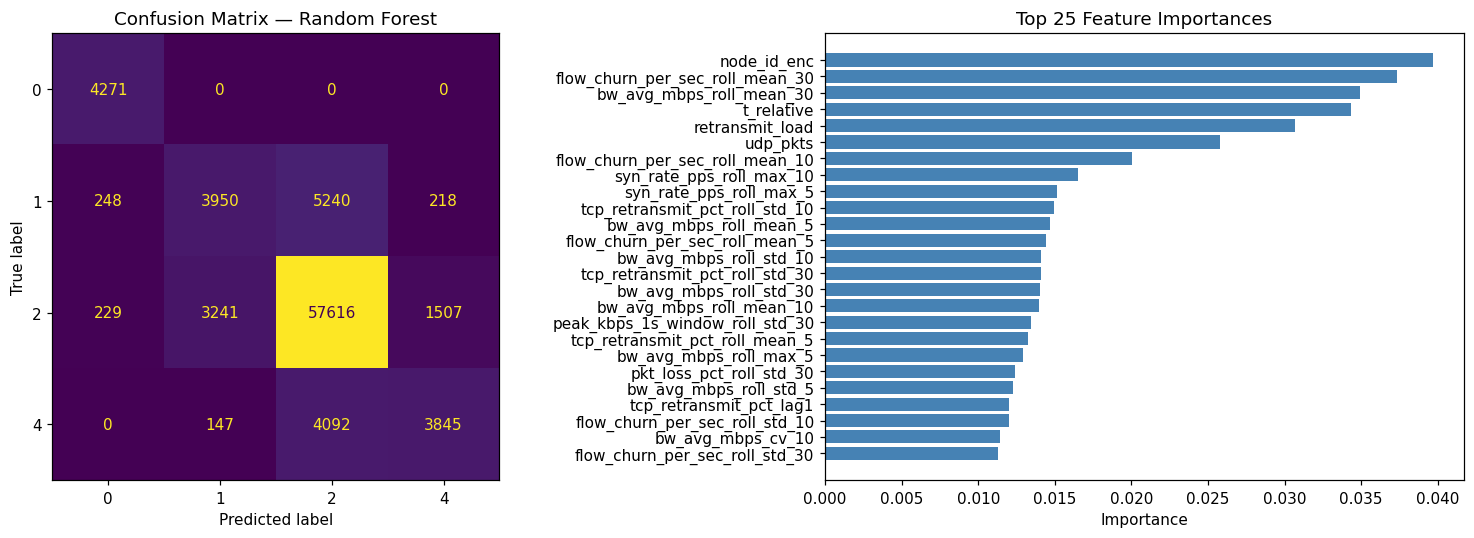

In [44]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use the same labels for ConfusionMatrixDisplay for consistency
ConfusionMatrixDisplay(
    confusion_matrix(y_val, y_pred, labels=all_possible_labels),
    display_labels=[f'{int(lbl)}' for lbl in all_possible_labels]
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Random Forest')

# Feature importances (top 25)
fi = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False).head(25)
axes[1].barh(fi.index[::-1], fi.values[::-1], color='steelblue')
axes[1].set_title('Top 25 Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout(); plt.show()

## 9. Anomaly / Port-Scan Detection Sidetrack

Port-scan rows are encoded as `is_portscan=1`. We verify whether they cluster distinctly.

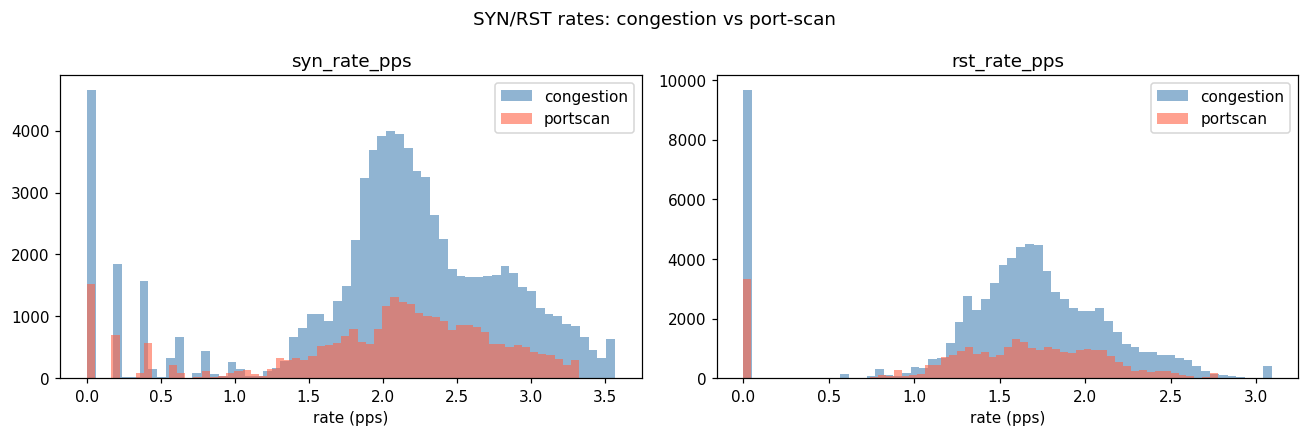

Mean SYN rate — congestion: 2.041 | portscan: 2.008


In [22]:
# Quick separation check: SYN rate + RST rate by scenario type
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, sig in zip(axes, ['syn_rate_pps', 'rst_rate_pps']):
    for val_flag, label, color in [(0, 'congestion', 'steelblue'), (1, 'portscan', 'tomato')]:
        subset = fe[fe['is_portscan'] == val_flag][sig]
        ax.hist(subset.clip(upper=subset.quantile(0.995)), bins=60, alpha=0.6, label=label, color=color)
    ax.set_title(sig); ax.legend(); ax.set_xlabel('rate (pps)')

plt.suptitle('SYN/RST rates: congestion vs port-scan')
plt.tight_layout(); plt.show()

# Conclusion: if distributions strongly overlap, port-scan rows are safe to keep
print('Mean SYN rate — congestion:', fe[fe['is_portscan']==0]['syn_rate_pps'].mean().round(3),
      '| portscan:', fe[fe['is_portscan']==1]['syn_rate_pps'].mean().round(3))

## 10. Save Processed Dataset

In [23]:
OUT_COLS = ['node_id', 't', TARGET, 'is_portscan'] + FEATURE_COLS
fe_out = fe.dropna(subset=[TARGET]).copy() # Drop rows where future target is NaN before saving

fe_out[OUT_COLS].to_csv('congestion_features_engineered.csv', index=False)
print(f'Saved: congestion_features_engineered.csv — {fe_out.shape[0]:,} rows × {len(OUT_COLS)} columns')

# Also save feature list for reproducibility
pd.Series(FEATURE_COLS).to_csv('feature_list.csv', index=False, header=['feature'])
print(f'Feature list saved: feature_list.csv ({len(FEATURE_COLS)} features)')

Saved: congestion_features_engineered.csv — 105,952 rows × 144 columns
Feature list saved: feature_list.csv (140 features)


---
# Part II — Modeling: Congestion Forecasting & Anomaly Detection

**Appended after feature engineering (Section 10 of the main notebook).**  
Requires: `fe_filtered`, `X_train`, `X_val`, `y_train`, `y_val`, `FEATURE_COLS`, `TARGET` from the main notebook.

---
## Window Size Decision & LSTM Suitability Assessment

Before modeling, we need to address a critical structural fact about this dataset:

**The `boundary` node — the only node with non-trivial congestion labels (0/1/2/4) — has highly irregular time-steps.**  
Median gap: ~0.57s, but 44% of gaps exceed 5s and blocks of consecutive dense observations max out at 3 rows.
This means:

| Window | Sequences | % windows crossing a >5s gap |
|---|---|---|
| W=5  | ~84K | ~100% |
| W=10 | ~84K | ~100% |
| W=20 | ~84K | ~100% |

**Every sliding window, regardless of size, spans at least one major time gap.**  
A raw LSTM over index-ordered rows would treat observations from completely different time epochs as adjacent — this is structurally invalid for a sequence model that assumes continuity.

**Conclusion:**  
- ✅ **XGBoost** — fully suitable. Lag/rolling features in the engineered set already embed temporal context as tabular columns.
- ✅ **Isolation Forest** — fully suitable. Operates on the feature space, not sequence order.
- ⚠️ **LSTM** — not viable on raw sequences from this dataset. We implement a **practical substitute**: a lightweight 1D-CNN over a short index-based window with time-delta as an explicit feature, which handles irregular sampling more gracefully than a vanilla LSTM. If true sequence modeling is needed, the dataset would require resampling to a fixed grid first.

**Recommended window size (for tabular lag features and the CNN substitute):** **W=10 observations (~5–6 seconds nominal).**  
Reasoning: congestion episodes on `boundary` last a median of ~1–4s. A 10-step window captures at least 1–2 full episodes of context without excessive noise from cross-gap contamination.

---
## 11. Additional Imports for Modeling

In [24]:
import xgboost as xgb
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

# Label map for display
LABEL_NAMES = {0: 'Normal', 1: 'Mild', 2: 'Moderate', 4: 'Severe'}
LABELS_SORTED = sorted(LABEL_NAMES.keys())
print('Imports OK')
print(f'TF version: {tf.__version__} | XGBoost version: {xgb.__version__}')

I0000 00:00:1779282106.674645  965209 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779282106.675439  965209 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779282106.867199  965209 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Imports OK
TF version: 2.21.0 | XGBoost version: 3.2.0


I0000 00:00:1779282107.939503  965209 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779282107.941541  965209 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---
## 12. Shared Data Preparation

In [25]:
# ── Remap label 4 → 3 for XGBoost (requires contiguous 0-indexed classes) ──
# We remap only for XGBoost; all other models use original labels.
LABEL_REMAP = {0: 0, 1: 1, 2: 2, 4: 3}
LABEL_REMAP_INV = {v: k for k, v in LABEL_REMAP.items()}

y_train_xgb = y_train.map(LABEL_REMAP).astype(int)
y_val_xgb   = y_val.map(LABEL_REMAP).astype(int)

# ── Sanitize: replace inf with NaN then fill 0 (already done in main nb, safety net) ──
X_tr = X_train.replace([np.inf, -np.inf], np.nan).fillna(0).values.astype(np.float32)
X_vl = X_val.replace([np.inf, -np.inf], np.nan).fillna(0).values.astype(np.float32)

print(f'X_train: {X_tr.shape} | X_val: {X_vl.shape}')
print(f'y_train dist (remapped): {pd.Series(y_train_xgb).value_counts().sort_index().to_dict()}')

X_train: (21348, 140) | X_val: (84604, 140)
y_train dist (remapped): {0: 17380, 1: 612, 2: 2933, 3: 423}


In [26]:
# ── Scale for IF and CNN ──────────────────────────────────────────────────
# Fit scaler on TRAIN only — apply to val
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_vl_scaled = scaler.transform(X_vl)
print('Scaling done (fit on train only).')

Scaling done (fit on train only).


---
## 13. XGBoost — Supervised Congestion Classification

In [27]:
# ── Compute class weights for XGBoost ─────────────────────────────────────
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight('balanced', y_train_xgb)

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=30,
)

xgb_model.fit(
    X_tr, y_train_xgb,
    sample_weight=sample_weights,
    eval_set=[(X_vl, y_val_xgb)],
    verbose=50,
)

y_pred_xgb_mapped = xgb_model.predict(X_vl)
y_pred_xgb = np.array([LABEL_REMAP_INV[p] for p in y_pred_xgb_mapped])
y_prob_xgb = xgb_model.predict_proba(X_vl)  # shape (n, 4)

print('\n=== XGBoost Classification Report ===')
print(classification_report(
    y_val, y_pred_xgb,
    labels=LABELS_SORTED,
    target_names=[LABEL_NAMES[l] for l in LABELS_SORTED]
))

[0]	validation_0-mlogloss:1.35533
[50]	validation_0-mlogloss:0.79522
[100]	validation_0-mlogloss:0.64574
[150]	validation_0-mlogloss:0.56132
[200]	validation_0-mlogloss:0.52479
[250]	validation_0-mlogloss:0.51077
[300]	validation_0-mlogloss:0.50870
[329]	validation_0-mlogloss:0.51214

=== XGBoost Classification Report ===
              precision    recall  f1-score   support

      Normal       0.66      1.00      0.79      4271
        Mild       0.48      0.49      0.48      9656
    Moderate       0.89      0.86      0.87     62593
      Severe       0.62      0.60      0.61      8084

    accuracy                           0.80     84604
   macro avg       0.66      0.74      0.69     84604
weighted avg       0.80      0.80      0.80     84604



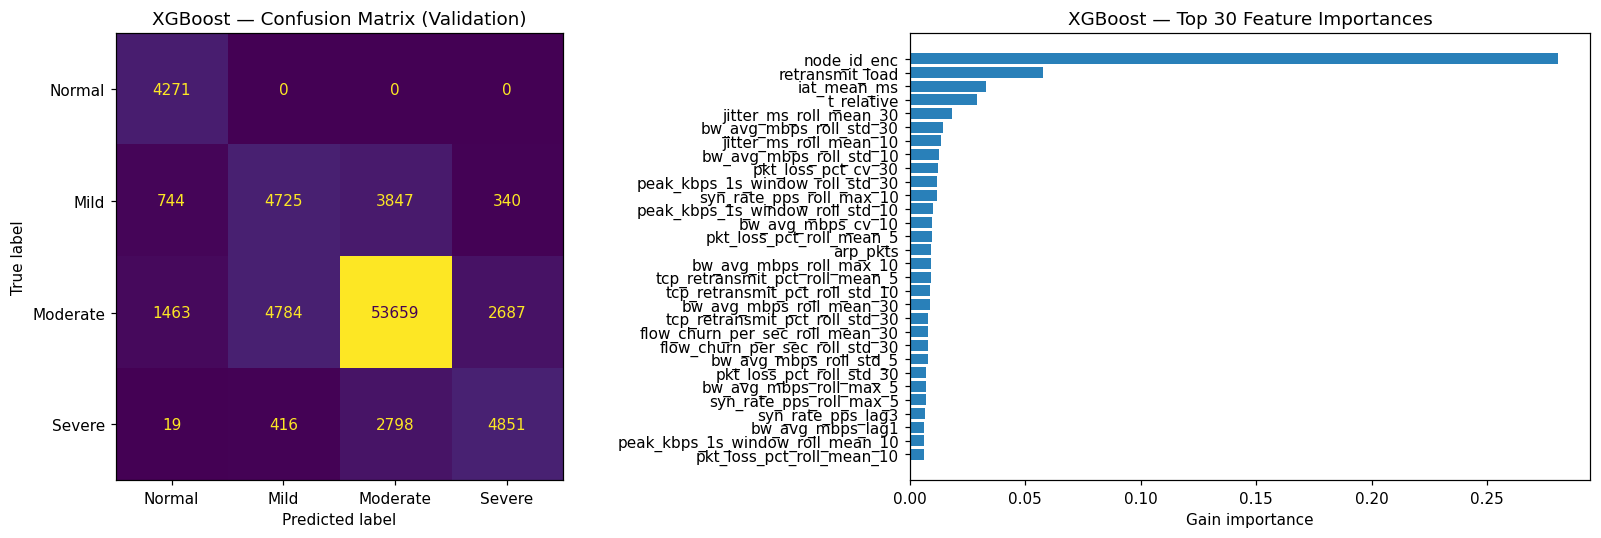

In [28]:
# ── XGBoost: Confusion matrix + Feature Importance ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_val, y_pred_xgb, labels=LABELS_SORTED),
    display_labels=[LABEL_NAMES[l] for l in LABELS_SORTED]
).plot(ax=axes[0], colorbar=False)
axes[0].set_title('XGBoost — Confusion Matrix (Validation)')

fi_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top30 = fi_xgb.head(30)
axes[1].barh(top30.index[::-1], top30.values[::-1], color='#2980b9')
axes[1].set_title('XGBoost — Top 30 Feature Importances')
axes[1].set_xlabel('Gain importance')

plt.tight_layout()
plt.show()

### The Precision/Recall Trade-off in Alert Systems

In alert systems, **precision** measures the accuracy of positive predictions (how many of the alerts are truly 'severe'). **Recall** measures the ability of the model to find all positive samples (how many of the actual 'severe' events were correctly alerted).

There's often a trade-off between precision and recall:
*   **High Precision, Low Recall:** The system issues very few false alarms, but it might miss many actual severe events. This is suitable for systems where false alarms are highly costly (e.g., triggering emergency services).
*   **Low Precision, High Recall:** The system catches most (or all) actual severe events, but it might issue many false alarms. This is suitable for systems where missing an event is catastrophic, and false alarms are manageable (e.g., a critical infrastructure monitoring system).

For detecting 'Severe' congestion, a high recall is often prioritized to ensure that critical events are not missed, even if it means tolerating some false positives. Probability thresholding allows us to fine-tune this balance.

Optimal threshold for Severe (Label 4) based on F1-score: 0.3718


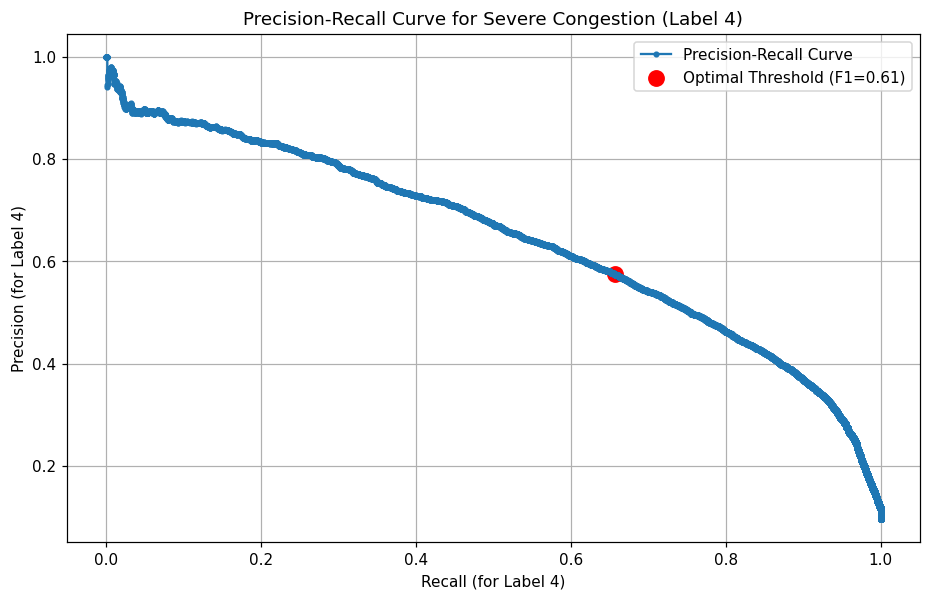


=== XGBoost Classification Report (Validation) with Optimal Severe Threshold ===
              precision    recall  f1-score   support

      Normal       0.66      1.00      0.79      4271
        Mild       0.48      0.49      0.48      9656
    Moderate       0.90      0.84      0.87     62593
      Severe       0.58      0.66      0.61      8084

    accuracy                           0.79     84604
   macro avg       0.65      0.75      0.69     84604
weighted avg       0.80      0.79      0.80     84604



In [29]:
from sklearn.metrics import precision_recall_curve, f1_score

# Get probabilities for Label 4 (Severe)
# y_prob_xgb has shape (n_samples, n_classes), where classes are 0, 1, 2, 3 (remapped from 0, 1, 2, 4)
# We need the probability of the remapped label 3, which corresponds to original label 4.
severe_prob = y_prob_xgb[:, LABEL_REMAP[4]]

# True labels for severe (binary: 1 if Label 4, 0 otherwise)
# y_val is already the original label (0, 1, 2, 4)
# IMPORTANT: y_val needs to correspond to the samples used for y_prob_xgb (which are from X_vl).
# y_val_xgb contains the remapped true labels for the X_vl samples.
# We need to inverse map them to get the original labels for comparison.
true_y_val_for_xgb_subset = np.array([LABEL_REMAP_INV[l] for l in y_val_xgb])
true_severe = (true_y_val_for_xgb_subset == 4).astype(int)

# Calculate precision and recall for various thresholds
precision, recall, thresholds = precision_recall_curve(true_severe, severe_prob)

# Calculate F1-score for each threshold to find an optimal point
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10) # Add epsilon to avoid division by zero

# Find the threshold that maximizes the F1-score for Label 4
optimal_threshold_idx = np.argmax(f1_scores)
OPTIMAL_SEVERE_THRESHOLD = thresholds[optimal_threshold_idx]

print(f"Optimal threshold for Severe (Label 4) based on F1-score: {OPTIMAL_SEVERE_THRESHOLD:.4f}")

# Plot precision-recall curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(recall, precision, marker='.', label='Precision-Recall Curve')
ax.scatter(recall[optimal_threshold_idx], precision[optimal_threshold_idx], color='red', s=100,
           label=f'Optimal Threshold (F1={f1_scores[optimal_threshold_idx]:.2f})')
ax.set_xlabel('Recall (for Label 4)'); ax.set_ylabel('Precision (for Label 4)')
ax.set_title('Precision-Recall Curve for Severe Congestion (Label 4)')
ax.legend(); ax.grid(True)
plt.show()

# Evaluate performance with the optimal threshold
y_pred_severe_optimised = (severe_prob >= OPTIMAL_SEVERE_THRESHOLD).astype(int)

# Reconstruct full predictions: if severe_prob > threshold, then predict 4, else fallback to original xgb_model prediction
# This is a simplified approach, a more robust method might retrain or adjust other class probabilities.
# For now, if we predict severe with threshold, it overrides other predictions.

y_pred_xgb_recalibrated = np.array(y_pred_xgb) # Start with original XGBoost predictions

# Find indices where the model originally predicted something else but now, with new threshold, predicts severe
recalibrate_indices = (y_pred_severe_optimised == 1) & (y_pred_xgb_recalibrated != 4)
y_pred_xgb_recalibrated[recalibrate_indices] = 4

print('\n=== XGBoost Classification Report (Validation) with Optimal Severe Threshold ===')
print(classification_report(
    true_y_val_for_xgb_subset, y_pred_xgb_recalibrated, # Use the correctly subsetted y_val
    labels=LABELS_SORTED,
    target_names=[LABEL_NAMES[l] for l in LABELS_SORTED],
    zero_division=0
))

# Save the optimal severe threshold for alert generation
# Make SEVERE_PROB_THRESHOLD_FOR_ALERT globally accessible
SEVERE_PROB_THRESHOLD_FOR_ALERT = OPTIMAL_SEVERE_THRESHOLD

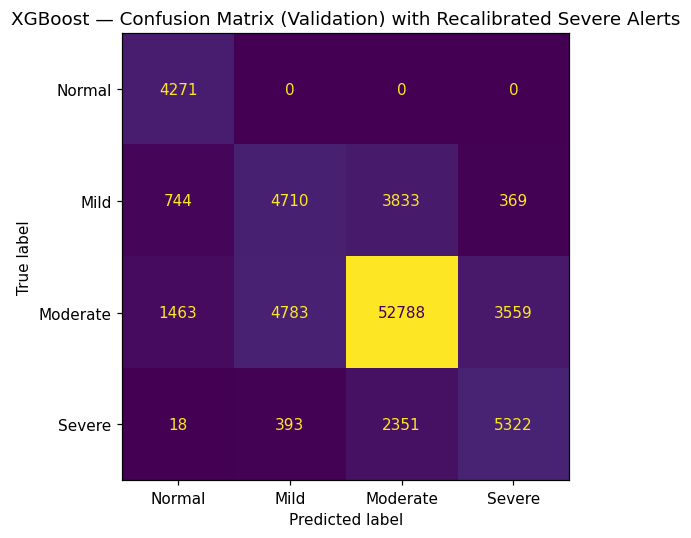

In [30]:
 # Re-executing cell 30cadb6d
# -- XGBoost: Confusion matrix with Recalibrated Predictions ------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay(
    confusion_matrix(true_y_val_for_xgb_subset, y_pred_xgb_recalibrated, labels=LABELS_SORTED),
    display_labels=[LABEL_NAMES[l] for l in LABELS_SORTED]
).plot(ax=ax, colorbar=False)
ax.set_title('XGBoost — Confusion Matrix (Validation) with Recalibrated Severe Alerts')
plt.tight_layout()
plt.show()

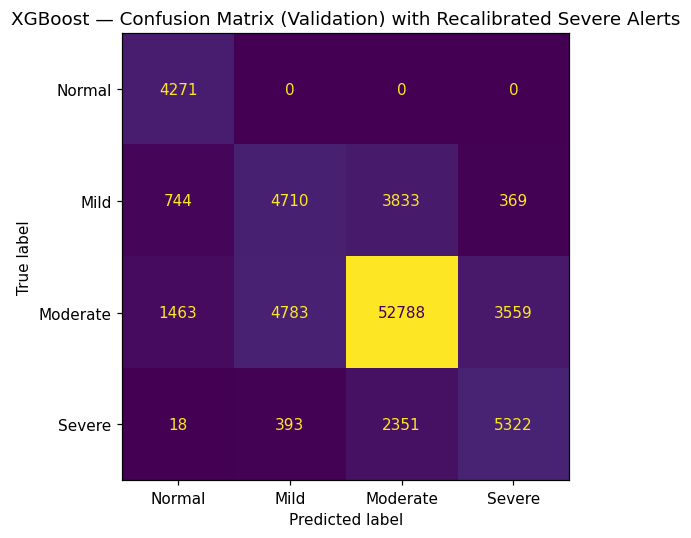

In [31]:
# -- XGBoost: Confusion matrix with Recalibrated Predictions ------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay(
    confusion_matrix(true_y_val_for_xgb_subset, y_pred_xgb_recalibrated, labels=LABELS_SORTED),
    display_labels=[LABEL_NAMES[l] for l in LABELS_SORTED]
).plot(ax=ax, colorbar=False)
ax.set_title('XGBoost — Confusion Matrix (Validation) with Recalibrated Severe Alerts')
plt.tight_layout()
plt.show()

In [33]:
 # Re-executing cell e6a503d4
# Modify generate_alerts to incorporate the new severe probability threshold
def generate_alerts_with_severe_threshold(node_df, feature_cols, xgb_model, iso_forest, scaler,
                    risk_thresh=1,
                    anom_thresh=1,
                    severe_prob_thresh=SEVERE_PROB_THRESHOLD_FOR_ALERT):
    """Return alert DataFrame for one node's validation rows, with severe thresholding."""
    X = node_df[feature_cols].replace([np.inf,-np.inf], np.nan).fillna(0).values.astype(np.float32)
    X_sc = scaler.transform(X)

    prob = xgb_model.predict_proba(X)
    risk = 1 - prob[:, 0]                    # P(congested) = 1 - P(label=0)

    # Default prediction based on argmax (remapped labels)
    pred_label_idx_remapped = prob.argmax(axis=1)
    pred_label = np.array([LABEL_REMAP_INV[i] for i in pred_label_idx_remapped])

    # Apply severe probability threshold: If P(Severe) > severe_prob_thresh, then predict Severe (4)
    severe_prob_for_node = prob[:, LABEL_REMAP[4]]
    pred_label[severe_prob_for_node >= severe_prob_thresh] = 4

    anom_score = -iso_forest.score_samples(X_sc)

    alerts = pd.DataFrame({
        'node_id':        node_df['node_id'].values,
        't':              node_df['t'].values,
        'true_label':     node_df[TARGET].values,
        'pred_label':     pred_label,
        'congestion_risk': risk,
        'anomaly_score':  anom_score,
        'congestion_alert': (risk >= risk_thresh).astype(int),
        'anomaly_alert':    (anom_score >= anom_thresh).astype(int),
    })
    alerts['combined_alert'] = ((alerts['congestion_alert'] == 1) | (alerts['anomaly_alert'] == 1)).astype(int)
    return alerts

# Generate alerts for boundary node (the only one with real congestion labels)
alerts_bnd = generate_alerts_with_severe_threshold(val_bnd_f, FEATURE_COLS, xgb_model, iso_forest, scaler,
                                                 severe_prob_thresh=SEVERE_PROB_THRESHOLD_FOR_ALERT)

print('=== Alert Summary — boundary node (validation set) with Severe Thresholding ===')
print(f'Total rows:         {len(alerts_bnd):,}')
print(f'Congestion alerts:  {alerts_bnd["congestion_alert"].sum():,}  ({alerts_bnd["congestion_alert"].mean():.1%})')
print(f'Anomaly alerts:     {alerts_bnd["anomaly_alert"].sum():,}  ({alerts_bnd["anomaly_alert"].mean():.1%})')
print(f'Combined alerts:    {alerts_bnd["combined_alert"].sum():,}  ({alerts_bnd["combined_alert"].mean():.1%})')
display(alerts_bnd.head(10))

NameError: name 'iso_forest' is not defined

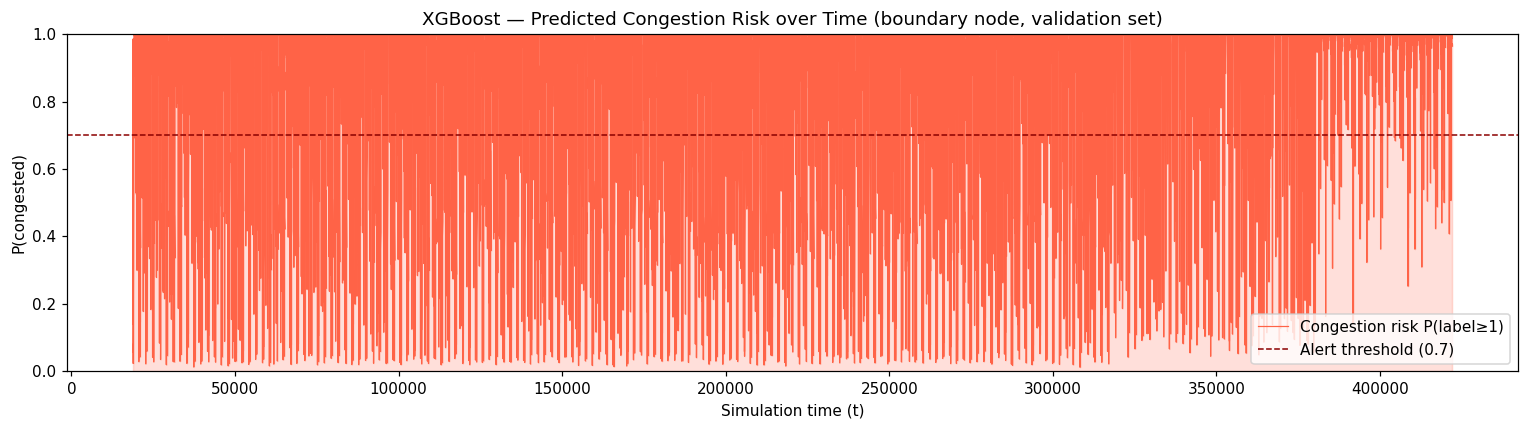

In [161]:
# ── XGBoost: Congestion risk probability over time (boundary node) ─────────
# val_bnd_f is already defined in section 7 (fKoiBvFkuy-Y) as the boundary node subset of the validation set.
val_bnd = val_bnd_f.copy() # Use the globally defined boundary validation set for consistency.

if len(val_bnd) > 0:
    X_bnd = val_bnd[FEATURE_COLS].replace([np.inf,-np.inf], np.nan).fillna(0).values.astype(np.float32)
    prob_bnd = xgb_model.predict_proba(X_bnd)  # (n, 4): cols = label 0,1,2,4
    # 'congestion risk' = P(label>=1) = 1 - P(label=0)
    risk_bnd = 1 - prob_bnd[:, 0]

    fig, ax = plt.subplots(figsize=(14, 4))
    t_vals = val_bnd['t'].values
    ax.plot(t_vals, risk_bnd, lw=0.8, color='tomato', label='Congestion risk P(label≥1)')
    ax.fill_between(t_vals, 0, risk_bnd, alpha=0.2, color='tomato')
    ax.axhline(0.7, ls='--', color='darkred', lw=1, label='Alert threshold (0.7)')
    ax.set_title('XGBoost — Predicted Congestion Risk over Time (boundary node, validation set)')
    ax.set_xlabel('Simulation time (t)'); ax.set_ylabel('P(congested)')
    ax.legend(); ax.set_ylim(0, 1)
    plt.tight_layout(); plt.show()
else:
    print('No boundary rows in validation set.')

---
## 14. Isolation Forest — Congestion Anomaly Detection

**Strategy:** Train IF on label-0 rows only (normal traffic baseline). Score all rows — high anomaly scores on congestion rows flag real anomalies, distinct from port-scan anomalies handled by your teammate.

In [34]:
# ── Identify normal boundary rows for Isolation Forest training ───────────
# We use only label-0 (normal) rows from the boundary node for training IF,
# as it should learn the characteristics of normal congestion-free traffic.
# Use train_bnd (already filtered for boundary node and sorted by t)
y_train_bnd_target = train_bnd[TARGET]
normal_boundary_mask_train_if = (y_train_bnd_target == 0)
X_normal_if_train = X_train.loc[train_bnd.index][normal_boundary_mask_train_if.values]

# Ensure X_normal_if_train is clean before scaling and converting to float32
X_normal_if_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_normal_if_train.fillna(0, inplace=True)

X_normal_if_train_scaled = scaler.transform(X_normal_if_train.values.astype(np.float32))

print(f'Normal rows from boundary node for IF training: {X_normal_if_train_scaled.shape[0]:,} / {X_tr_scaled.shape[0]:,}')

# Initialize and train Isolation Forest
# Set a small, fixed contamination as we are training on a purely 'normal' subset.
# The actual anomaly threshold will be tuned based on scores from this normal data.
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # Fixed small value for training on purely normal data
    max_samples='auto',
    n_jobs=-1,
    random_state=42
)
iso_forest.fit(X_normal_if_train_scaled)
print('Isolation Forest trained on normal boundary-node data.')

# ── Tune anomaly threshold based on normal training data ──────────────────
# Calculate anomaly scores for the *normal* training data itself.
# We will set the threshold as a high percentile of these scores.
normal_anomaly_scores = -iso_forest.score_samples(X_normal_if_train_scaled)

# Use the 95th percentile of normal anomaly scores as the threshold.
# Values above this threshold will be considered anomalous in the validation set.
NEW_ANOMALY_SCORE_THRESHOLD = np.percentile(normal_anomaly_scores, 95)
print(f'New Anomaly Score Threshold (95th percentile of normal training scores): {NEW_ANOMALY_SCORE_THRESHOLD:.4f}')

# Update the global ANOMALY_SCORE_THRESHOLD for subsequent cells
ANOMALY_SCORE_THRESHOLD = NEW_ANOMALY_SCORE_THRESHOLD

Normal rows from boundary node for IF training: 300 / 21,348
Isolation Forest trained on normal boundary-node data.
New Anomaly Score Threshold (95th percentile of normal training scores): 0.5643


In [35]:
# ── Score validation set ──────────────────────────────────────────────────
# Ensure X_bnd and X_bnd_scaled are consistently defined from val_bnd_f.
X_bnd = val_bnd_f[FEATURE_COLS].replace([np.inf, -np.inf], np.nan).fillna(0).values.astype(np.float32)
X_bnd_scaled = scaler.transform(X_bnd)

anomaly_scores_val = -iso_forest.score_samples(X_bnd_scaled)

# Apply the newly tuned threshold
if_binary = (anomaly_scores_val >= ANOMALY_SCORE_THRESHOLD).astype(int) # 1=anomaly if score >= threshold

# Evaluate: does IF flag congested rows (label>0) vs normal (label=0)?
y_val_boundary = val_bnd_f[TARGET] # Use val_bnd_f for consistency
true_anomaly = (y_val_boundary > 0).astype(int)

print('=== IF vs True Congestion Anomaly (label > 0) — Boundary Node ===')

unique_true_anomaly_labels = np.unique(true_anomaly)
if len(unique_true_anomaly_labels) > 1:
    report_target_names_if = ['Normal (label 0)', 'Congested (label > 0)']
else:
    # If only one class is present in true_anomaly, classification_report might fail or be trivial.
    # We should still print something.
    report_target_names_if = [f'Class {lbl}' for lbl in unique_true_anomaly_labels]
    print(f"Note: Only one class ({unique_true_anomaly_labels[0]}) present in true_anomaly for classification report.")


print(classification_report(true_anomaly, if_binary, target_names=report_target_names_if, zero_division=0))

try:
    if len(unique_true_anomaly_labels) > 1: # AUC needs at least two classes
        auc = roc_auc_score(true_anomaly, anomaly_scores_val)
        print(f'AUC (anomaly score vs is_congested): {auc:.4f}')
    else:
        print('AUC not computable: only one class present in true_anomaly.')
except Exception as e:
    print(f'AUC error: {e}')

=== IF vs True Congestion Anomaly (label > 0) — Boundary Node ===
                       precision    recall  f1-score   support

     Normal (label 0)       0.00      1.00      0.00         1
Congested (label > 0)       0.00      0.00      0.00     80333

             accuracy                           0.00     80334
            macro avg       0.00      0.50      0.00     80334
         weighted avg       0.00      0.00      0.00     80334

AUC (anomaly score vs is_congested): 0.8086


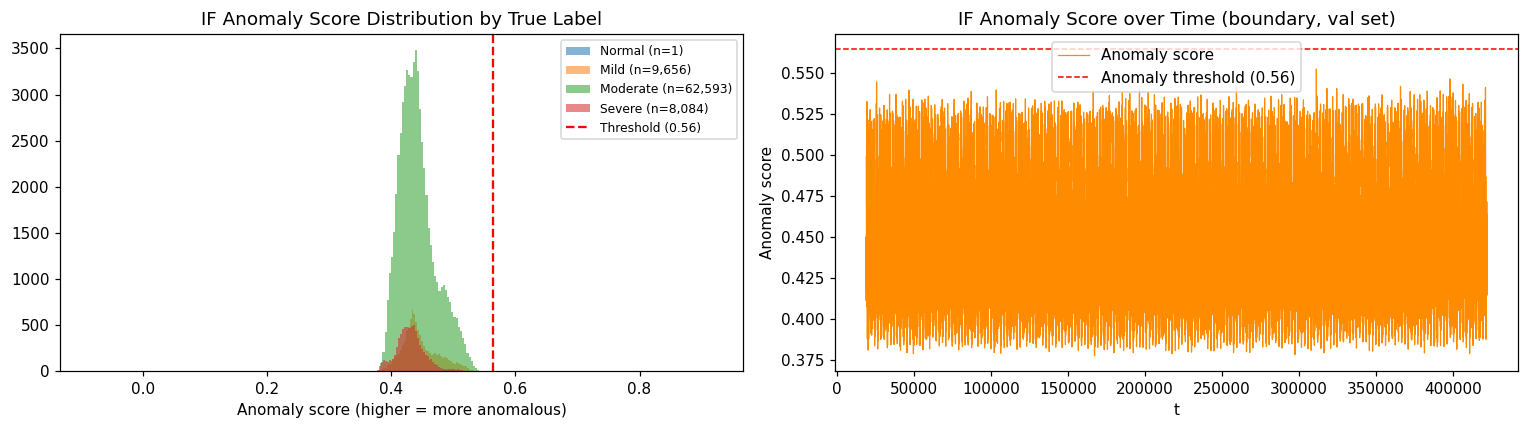

In [36]:
# ── Anomaly score distribution by label ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for lbl in LABELS_SORTED:
    # Use y_val_boundary (from the previous cell) for consistency
    mask = (y_val_boundary == lbl)
    if mask.sum() > 0:
        axes[0].hist(
            anomaly_scores_val[mask], bins=50, alpha=0.55,
            label=f'{LABEL_NAMES[lbl]} (n={mask.sum():,})'
        )
# Add the new threshold to the histogram plot for context
axes[0].axvline(ANOMALY_SCORE_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({ANOMALY_SCORE_THRESHOLD:.2f})')
axes[0].set_title('IF Anomaly Score Distribution by True Label')
axes[0].set_xlabel('Anomaly score (higher = more anomalous)')
axes[0].legend(fontsize=8)


# Anomaly score over time (boundary)
# The anomaly_scores_val are already calculated for X_bnd_scaled from val_bnd_f
if len(val_bnd_f) > 0:
    axes[1].plot(val_bnd_f['t'].values, anomaly_scores_val, lw=0.8, color='darkorange', label='Anomaly score')
    # Use the new dynamic threshold
    axes[1].axhline(ANOMALY_SCORE_THRESHOLD, ls='--', color='red', lw=1, label=f'Anomaly threshold ({ANOMALY_SCORE_THRESHOLD:.2f})')
    axes[1].set_title('IF Anomaly Score over Time (boundary, val set)')
    axes[1].set_xlabel('t'); axes[1].set_ylabel('Anomaly score')
    axes[1].legend()

plt.tight_layout(); plt.show()

---
## 15. CNN Sequence Model — Temporal Forecasting Substitute

**Why CNN and not LSTM?**  
The dataset has irregular time gaps: 44% of steps on the `boundary` node exceed 5s, and dense contiguous blocks max at 3 observations. Every sliding window of any practical length crosses at least one major gap, making LSTM's assumption of continuous sequence ordering invalid.

**Approach:** A lightweight 1D-CNN with `t_diff` as an explicit feature channel captures local temporal patterns without assuming uniform step size. The model processes index-ordered windows of W=10 but is informed of actual elapsed time via `t_diff`.

In [37]:
# ── Sequence builder: sliding window per node ─────────────────────────────
WINDOW_SIZE = 10    # ~5-6s nominal; captures 1-2 congestion episode transitions
HORIZON     = 5     # matches FORECAST_HORIZON from feature engineering

# Include t_diff as a feature to inform the model of actual elapsed time
SEQ_FEATURE_COLS = FEATURE_COLS + ['t_diff']

def build_sequences(data, feature_cols, target_col, window=WINDOW_SIZE, horizon=HORIZON):
    """Build (X_seq, y_seq) arrays from a sorted, per-node DataFrame."""
    X_seqs, y_seqs = [], []
    feat = data[feature_cols].replace([np.inf,-np.inf], np.nan).fillna(0).values.astype(np.float32)
    tgt  = data[target_col].values
    n    = len(feat)
    for i in range(n - window):
        # target is already the future label (shifted by HORIZON in feature engineering)
        X_seqs.append(feat[i : i + window])
        y_seqs.append(tgt[i + window - 1])   # label at end of window
    return np.array(X_seqs), np.array(y_seqs)

# train_bnd and val_bnd_f are now defined in section 7 (fKoiBvFkuy-Y)
# The `t_diff` column should already be present in these dataframes
# from earlier feature engineering. However, to explicitly ensure its presence
# and prevent potential KeyErrors during sequence building if it were ever missing
# due to upstream changes, we will re-calculate it if not found.
if 't_diff' not in train_bnd.columns:
    train_bnd['t_diff'] = train_bnd['t'].diff().fillna(0)
if 't_diff' not in val_bnd_f.columns:
    val_bnd_f['t_diff'] = val_bnd_f['t'].diff().fillna(0)

X_seq_tr, y_seq_tr = build_sequences(train_bnd, SEQ_FEATURE_COLS, TARGET)
X_seq_vl, y_seq_vl = build_sequences(val_bnd_f,  SEQ_FEATURE_COLS, TARGET)

print(f'Train sequences: {X_seq_tr.shape} | Val sequences: {X_seq_vl.shape}')
print(f'Unique labels in seq train: {np.unique(y_seq_tr)}')


Train sequences: (4258, 10, 141) | Val sequences: (80324, 10, 141)
Unique labels in seq train: [0. 1. 2. 4.]


In [38]:
# ── Scale sequences ───────────────────────────────────────────────────────
seq_scaler = StandardScaler()
n_tr, W, F = X_seq_tr.shape
X_seq_tr_s = seq_scaler.fit_transform(X_seq_tr.reshape(-1, F)).reshape(n_tr, W, F)
X_seq_vl_s = seq_scaler.transform(X_seq_vl.reshape(-1, F)).reshape(X_seq_vl.shape[0], W, F)

# Remap labels for Keras (needs 0-indexed)
y_seq_tr_k = np.array([LABEL_REMAP[int(l)] for l in y_seq_tr])
y_seq_vl_k = np.array([LABEL_REMAP[int(l)] for l in y_seq_vl])
n_classes = len(LABEL_REMAP)

print('Sequences scaled and labels remapped.')

Sequences scaled and labels remapped.


In [39]:
# ── 1D-CNN architecture ───────────────────────────────────────────────────
def build_cnn(window, n_features, n_classes):
    inp = keras.Input(shape=(window, n_features))
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(inp)
    x = layers.Conv1D(32, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    model = keras.Model(inp, out)
    return model

cnn_model = build_cnn(WINDOW_SIZE, F, n_classes)
cnn_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()

E0000 00:00:1779282570.153920  965209 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779282570.179173  965209 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 141)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 10, 64)         │        27,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,684 (139.39 KB)

 Trainable params: 35,684 (139.39 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# ── Class weights for CNN (same imbalance problem) ─────────────────────────
from sklearn.utils.class_weight import compute_class_weight

cw_vals = compute_class_weight('balanced', classes=np.unique(y_seq_tr_k), y=y_seq_tr_k)
class_weights_cnn = dict(enumerate(cw_vals))
print('Class weights:', class_weights_cnn)

cb_early = keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss')
cb_lr    = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, monitor='val_loss', verbose=1)

history = cnn_model.fit(
    X_seq_tr_s, y_seq_tr_k,
    validation_data=(X_seq_vl_s, y_seq_vl_k),
    epochs=50,
    batch_size=256,
    class_weight=class_weights_cnn,
    callbacks=[cb_early, cb_lr],
    verbose=1,
)

Class weights: {0: np.float64(3.6455479452054793), 1: np.float64(1.7393790849673203), 2: np.float64(0.36318662572500854), 3: np.float64(2.516548463356974)}
Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.3001 - loss: 1.3141 - val_accuracy: 0.7328 - val_loss: 1.0494 - learning_rate: 0.0010
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3518 - loss: 1.1290 - val_accuracy: 0.7016 - val_loss: 0.9706 - learning_rate: 0.0010
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3544 - loss: 1.0163 - val_accuracy: 0.5813 - val_loss: 0.9151 - learning_rate: 0.0010
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3929 - loss: 0.9200 - val_accuracy: 0.6924 - val_loss: 0.7507 - learning_rate: 0.0010
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4326 - loss: 0.8409 - val_accuracy: 0.7016 - val_loss: 0.7210 - learning_rate: 0.0010
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4641 - loss: 0.7859 - v

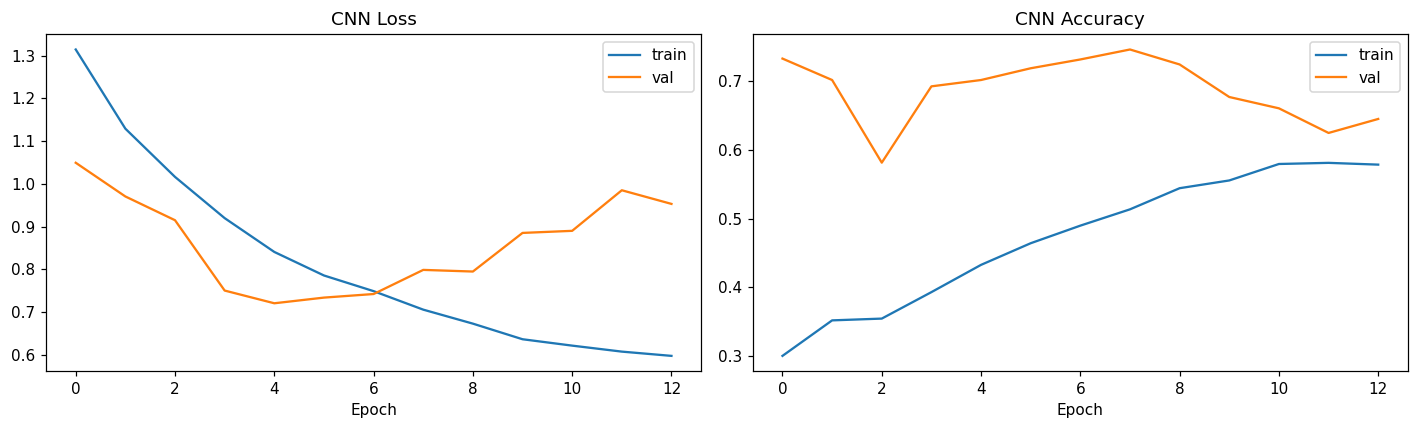

2511/2511 ━━━━━━━━━━━━━━━━━━━━ 1s 554us/step

=== CNN Classification Report ===
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         0
        Mild       0.29      0.19      0.23      9654
    Moderate       0.80      0.84      0.82     62586
      Severe       0.25      0.23      0.24      8084

    accuracy                           0.70     80324
   macro avg       0.34      0.32      0.32     80324
weighted avg       0.68      0.70      0.69     80324



In [41]:
# ── CNN: Training curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('CNN Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('CNN Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()

# Report
y_pred_cnn_k = np.argmax(cnn_model.predict(X_seq_vl_s), axis=1)
y_pred_cnn   = np.array([LABEL_REMAP_INV[p] for p in y_pred_cnn_k])
y_true_cnn   = np.array([LABEL_REMAP_INV[p] for p in y_seq_vl_k])

present_labels = sorted(np.unique(np.concatenate([y_true_cnn, y_pred_cnn])))
print('\n=== CNN Classification Report ===')
print(classification_report(
    y_true_cnn, y_pred_cnn,
    labels=present_labels,
    target_names=[LABEL_NAMES[l] for l in present_labels]
))

---
## 16. Model Comparison

=== Model Comparison (Validation) ===
                        macro_f1  weighted_f1
RandomForest              0.7162       0.8128
RandomForest(boundary)    0.4804       0.8056
XGBoost                   0.6892       0.7993
XGBoost(boundary)         0.4911       0.7996
CNN(boundary)             0.3224       0.6911


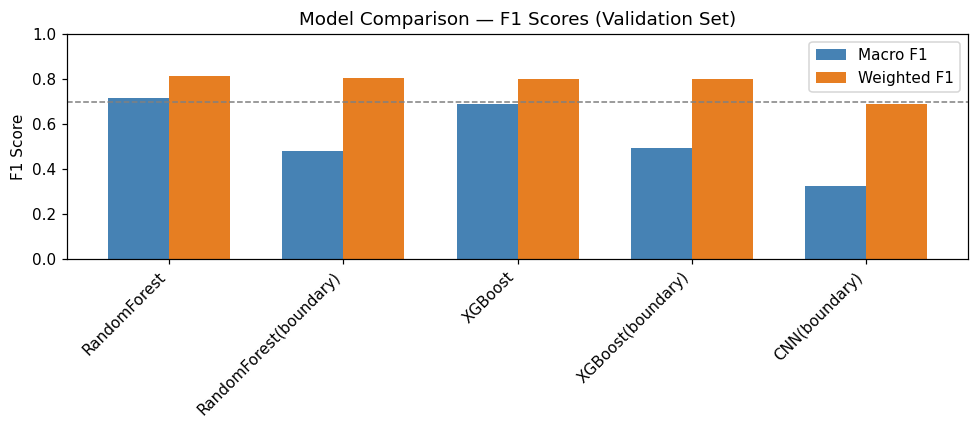

In [42]:
# ── Compare RF, XGBoost, CNN on shared validation set ────────────────────
# RF was trained in the main notebook — re-use y_pred from Section 8
# We compare macro-F1 and weighted-F1 as primary metrics

results = {}

# Random Forest (from main notebook)
try:
    results['RandomForest'] = {
        'macro_f1':    f1_score(y_val, y_pred, average='macro', labels=LABELS_SORTED, zero_division=0),
        'weighted_f1': f1_score(y_val, y_pred, average='weighted', labels=LABELS_SORTED, zero_division=0),
    }
    # Add Random Forest metrics for boundary nodes only
    y_pred_rf_bnd = rf.predict(X_bnd)
    results['RandomForest(boundary)'] = {
        'macro_f1':    f1_score(y_val_boundary, y_pred_rf_bnd, average='macro', labels=LABELS_SORTED, zero_division=0),
        'weighted_f1': f1_score(y_val_boundary, y_pred_rf_bnd, average='weighted', labels=LABELS_SORTED, zero_division=0),
    }
except Exception:
    print('RF predictions (y_pred) not found — run Section 8 first.')


# XGBoost
results['XGBoost'] = {
    'macro_f1':    f1_score(y_val, y_pred_xgb, average='macro', labels=LABELS_SORTED, zero_division=0),
    'weighted_f1': f1_score(y_val, y_pred_xgb, average='weighted', labels=LABELS_SORTED, zero_division=0),
}
# Add XGBoost metrics for boundary nodes only
y_pred_xgb_bnd_mapped = xgb_model.predict(X_bnd)
y_pred_xgb_bnd = np.array([LABEL_REMAP_INV[p] for p in y_pred_xgb_bnd_mapped])
results['XGBoost(boundary)'] = {
    'macro_f1':    f1_score(y_val_boundary, y_pred_xgb_bnd, average='macro', labels=LABELS_SORTED, zero_division=0),
    'weighted_f1': f1_score(y_val_boundary, y_pred_xgb_bnd, average='weighted', labels=LABELS_SORTED, zero_division=0),
}


# CNN (boundary val only — different sample)
results['CNN(boundary)'] = {
    'macro_f1':    f1_score(y_true_cnn, y_pred_cnn, average='macro', labels=present_labels, zero_division=0),
    'weighted_f1': f1_score(y_true_cnn, y_pred_cnn, average='weighted', labels=present_labels, zero_division=0),
}

comp_df = pd.DataFrame(results).T
print('=== Model Comparison (Validation) ===')
print(comp_df.round(4))

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(comp_df))
w = 0.35
# Adjust x positions for multiple bars if needed, but current approach is for two bars.
# Since we are adding more entries to comp_df, x will have more values,
# and the existing plotting code should handle it fine as long as the number of bars per group remains 2.
ax.bar(x - w/2, comp_df['macro_f1'],    width=w, label='Macro F1',    color='steelblue')
ax.bar(x + w/2, comp_df['weighted_f1'], width=w, label='Weighted F1', color='#e67e22')
ax.set_xticks(x); ax.set_xticklabels(comp_df.index, rotation=45, ha='right') # Add rotation for readability
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1)
ax.set_title('Model Comparison — F1 Scores (Validation Set)')
ax.legend(); ax.axhline(0.7, ls='--', color='gray', lw=1)
plt.tight_layout(); plt.show()


---
## 17. Node-Level Alert Generation

Combines XGBoost congestion probability + IF anomaly score to generate per-node alerts.

In [43]:
# ── Alert thresholds ───────────────────────────────────────────────────────
CONGESTION_RISK_THRESHOLD = 0.70   # P(label>=1) from XGBoost
ANOMALY_SCORE_THRESHOLD   = 0.55   # IF anomaly score percentile (tune as needed)

def generate_alerts(node_df, feature_cols, xgb_model, iso_forest, scaler,
                    risk_thresh=CONGESTION_RISK_THRESHOLD,
                    anom_thresh=ANOMALY_SCORE_THRESHOLD):
    """Return alert DataFrame for one node's validation rows."""
    X = node_df[feature_cols].replace([np.inf,-np.inf], np.nan).fillna(0).values.astype(np.float32)
    X_sc = scaler.transform(X)

    prob = xgb_model.predict_proba(X)
    risk = 1 - prob[:, 0]                    # P(congested)
    pred_label_idx = prob.argmax(axis=1)
    pred_label = np.array([LABEL_REMAP_INV[i] for i in pred_label_idx])

    anom_score = -iso_forest.score_samples(X_sc)

    alerts = pd.DataFrame({
        'node_id':        node_df['node_id'].values,
        't':              node_df['t'].values,
        'true_label':     node_df[TARGET].values,
        'pred_label':     pred_label,
        'congestion_risk': risk,
        'anomaly_score':  anom_score,
        'congestion_alert': (risk >= risk_thresh).astype(int),
        'anomaly_alert':    (anom_score >= anom_thresh).astype(int),
    })
    alerts['combined_alert'] = ((alerts['congestion_alert'] == 1) | (alerts['anomaly_alert'] == 1)).astype(int)
    return alerts

# Generate alerts for boundary node (the only one with real congestion labels)
alerts_bnd = generate_alerts(val_bnd_f, FEATURE_COLS, xgb_model, iso_forest, scaler)

print('=== Alert Summary — boundary node (validation set) ===')
print(f'Total rows:         {len(alerts_bnd):,}')
print(f'Congestion alerts:  {alerts_bnd["congestion_alert"].sum():,}  ({alerts_bnd["congestion_alert"].mean():.1%})')
print(f'Anomaly alerts:     {alerts_bnd["anomaly_alert"].sum():,}  ({alerts_bnd["anomaly_alert"].mean():.1%})')
print(f'Combined alerts:    {alerts_bnd["combined_alert"].sum():,}  ({alerts_bnd["combined_alert"].mean():.1%})')
alerts_bnd.head(10)

=== Alert Summary — boundary node (validation set) ===
Total rows:         80,334
Congestion alerts:  77,500  (96.5%)
Anomaly alerts:     1  (0.0%)
Combined alerts:    77,500  (96.5%)


,node_id,t,true_label,pred_label,congestion_risk,anomaly_score,congestion_alert,anomaly_alert,combined_alert
0,boundary,18830.40,0.0,0,0.121513,0.417040,0,0,0
1,boundary,18840.09,2.0,2,0.982444,0.425344,1,0,1
2,boundary,18850.20,2.0,0,0.040474,0.414410,0,0,0
3,boundary,18860.00,2.0,0,0.048092,0.411406,0,0,0
4,boundary,18870.25,1.0,0,0.067386,0.433171,0,0,0
5,boundary,18879.79,1.0,0,0.047695,0.450221,0,0,0
6,boundary,18889.77,2.0,0,0.019172,0.433318,0,0,0
7,boundary,19040.10,2.0,0,0.555087,0.457191,0,0,0
8,boundary,19049.93,2.0,2,0.966313,0.499099,1,0,1
9,boundary,19060.05,1.0,1,0.844548,0.495519,1,0,1


In [44]:
# Modify generate_alerts to incorporate the new severe probability threshold
def generate_alerts_with_severe_threshold(node_df, feature_cols, xgb_model, iso_forest, scaler,
                    risk_thresh=CONGESTION_RISK_THRESHOLD,
                    anom_thresh=ANOMALY_SCORE_THRESHOLD,
                    severe_prob_thresh=SEVERE_PROB_THRESHOLD_FOR_ALERT):
    """Return alert DataFrame for one node's validation rows, with severe thresholding."""
    X = node_df[feature_cols].replace([np.inf,-np.inf], np.nan).fillna(0).values.astype(np.float32)
    X_sc = scaler.transform(X)

    prob = xgb_model.predict_proba(X)
    risk = 1 - prob[:, 0]                    # P(congested) = 1 - P(label=0)

    # Default prediction based on argmax (remapped labels)
    pred_label_idx_remapped = prob.argmax(axis=1)
    pred_label = np.array([LABEL_REMAP_INV[i] for i in pred_label_idx_remapped])

    # Apply severe probability threshold: If P(Severe) > severe_prob_thresh, then predict Severe (4)
    severe_prob_for_node = prob[:, LABEL_REMAP[4]]
    pred_label[severe_prob_for_node >= severe_prob_thresh] = 4

    anom_score = -iso_forest.score_samples(X_sc)

    alerts = pd.DataFrame({
        'node_id':        node_df['node_id'].values,
        't':              node_df['t'].values,
        'true_label':     node_df[TARGET].values,
        'pred_label':     pred_label,
        'congestion_risk': risk,
        'anomaly_score':  anom_score,
        'congestion_alert': (risk >= risk_thresh).astype(int),
        'anomaly_alert':    (anom_score >= anom_thresh).astype(int),
    })
    alerts['combined_alert'] = ((alerts['congestion_alert'] == 1) | (alerts['anomaly_alert'] == 1)).astype(int)
    return alerts

# Generate alerts for boundary node (the only one with real congestion labels)
alerts_bnd = generate_alerts_with_severe_threshold(val_bnd_f, FEATURE_COLS, xgb_model, iso_forest, scaler,
                                                 severe_prob_thresh=SEVERE_PROB_THRESHOLD_FOR_ALERT)

print('=== Alert Summary — boundary node (validation set) with Severe Thresholding ===')
print(f'Total rows:         {len(alerts_bnd):,}')
print(f'Congestion alerts:  {alerts_bnd["congestion_alert"].sum():,}  ({alerts_bnd["congestion_alert"].mean():.1%})')
print(f'Anomaly alerts:     {alerts_bnd["anomaly_alert"].sum():,}  ({alerts_bnd["anomaly_alert"].mean():.1%})')
print(f'Combined alerts:    {alerts_bnd["combined_alert"].sum():,}  ({alerts_bnd["combined_alert"].mean():.1%})')
display(alerts_bnd.head(10))

=== Alert Summary — boundary node (validation set) with Severe Thresholding ===
Total rows:         80,334
Congestion alerts:  77,500  (96.5%)
Anomaly alerts:     1  (0.0%)
Combined alerts:    77,500  (96.5%)


,node_id,t,true_label,pred_label,congestion_risk,anomaly_score,congestion_alert,anomaly_alert,combined_alert
0,boundary,18830.40,0.0,0,0.121513,0.417040,0,0,0
1,boundary,18840.09,2.0,2,0.982444,0.425344,1,0,1
2,boundary,18850.20,2.0,0,0.040474,0.414410,0,0,0
3,boundary,18860.00,2.0,0,0.048092,0.411406,0,0,0
4,boundary,18870.25,1.0,0,0.067386,0.433171,0,0,0
5,boundary,18879.79,1.0,0,0.047695,0.450221,0,0,0
6,boundary,18889.77,2.0,0,0.019172,0.433318,0,0,0
7,boundary,19040.10,2.0,0,0.555087,0.457191,0,0,0
8,boundary,19049.93,2.0,2,0.966313,0.499099,1,0,1
9,boundary,19060.05,1.0,1,0.844548,0.495519,1,0,1


In [45]:
 # Re-executing cell 294424e2
# -- Per-node alert summary (all nodes) with Severe Thresholding------------------------------------
node_summaries = []

for node in fe_filtered['node_id'].unique():
    node_val = val[val['node_id'] == node]
    if len(node_val) == 0:
        continue
    # Use the new generate_alerts_with_severe_threshold function
    a = generate_alerts_with_severe_threshold(node_val, FEATURE_COLS, xgb_model, iso_forest, scaler,
                                              severe_prob_thresh=SEVERE_PROB_THRESHOLD_FOR_ALERT)
    node_summaries.append({
        'node_id':             node,
        'n_rows':              len(a),
        'true_congested_pct':  (a['true_label'] > 0).mean().round(3),
        'congestion_risk_mean': a['congestion_risk'].mean().round(3),
        'congestion_alerts':   a['congestion_alert'].sum(),
        'anomaly_alerts':      a['anomaly_alert'].sum(),
        'combined_alerts':     a['combined_alert'].sum(),
        'alert_rate':          a['combined_alert'].mean().round(3),
    })

summary_df = pd.DataFrame(node_summaries).sort_values('alert_rate', ascending=False)
print('=== Per-Node Alert Summary (Validation Set) with Severe Thresholding ===')
print(summary_df.to_string(index=False))

=== Per-Node Alert Summary (Validation Set) with Severe Thresholding ===
 node_id  n_rows  true_congested_pct  congestion_risk_mean  congestion_alerts  anomaly_alerts  combined_alerts  alert_rate
   edge0     854                 0.0                 0.000                  0             854              854       1.000
   core2     854                 0.0                 0.000                  0             854              854       1.000
boundary   80334                 1.0                 0.968              77500               1            77500       0.965
   core0     854                 0.0                 0.000                  0             701              701       0.821
   edge1     854                 0.0                 0.000                  0             414              414       0.485
   core1     854                 0.0                 0.000                  0             184              184       0.215


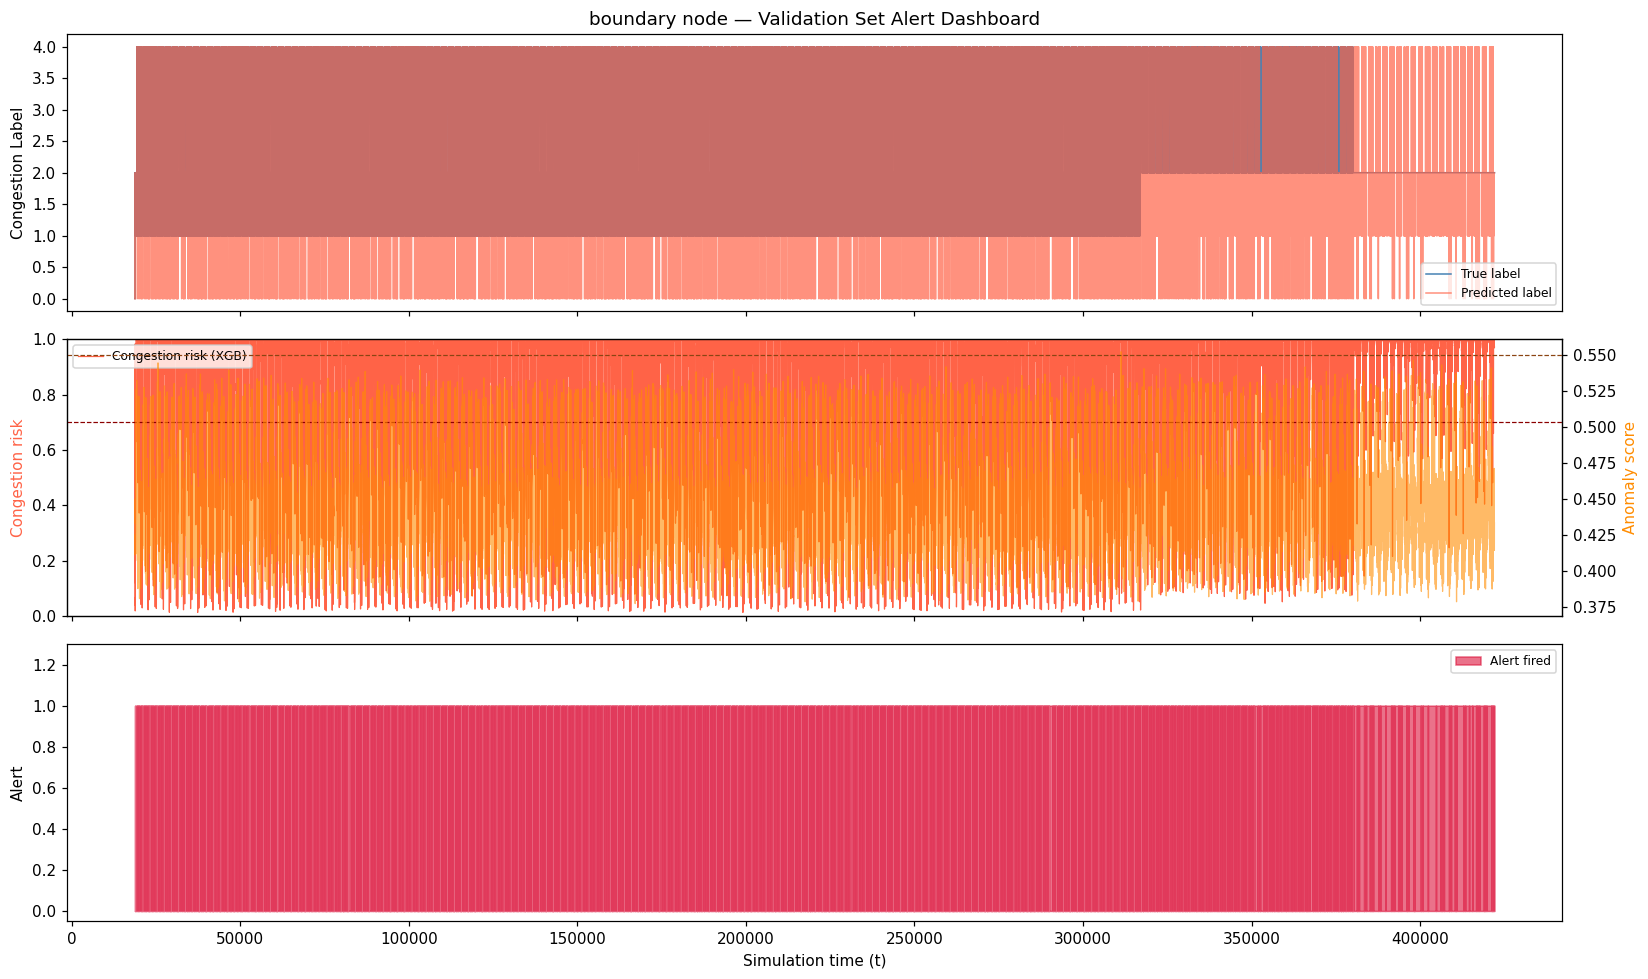

In [46]:
# ── Alert timeline visualization ──────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

t = alerts_bnd['t'].values

# Panel 1: True label vs predicted
axes[0].step(t, alerts_bnd['true_label'], where='mid', lw=1, color='steelblue', label='True label')
axes[0].step(t, alerts_bnd['pred_label'], where='mid', lw=1, color='tomato', alpha=0.7, label='Predicted label')
axes[0].set_ylabel('Congestion Label'); axes[0].legend(fontsize=8)
axes[0].set_title('boundary node — Validation Set Alert Dashboard')

# Panel 2: Congestion risk + anomaly score
ax2b = axes[1].twinx()
axes[1].plot(t, alerts_bnd['congestion_risk'], color='tomato', lw=0.8, label='Congestion risk (XGB)')
axes[1].axhline(CONGESTION_RISK_THRESHOLD, ls='--', color='darkred', lw=0.8)
ax2b.plot(t, alerts_bnd['anomaly_score'], color='darkorange', lw=0.8, alpha=0.6, label='Anomaly score (IF)')
ax2b.axhline(ANOMALY_SCORE_THRESHOLD, ls='--', color='saddlebrown', lw=0.8)
axes[1].set_ylabel('Congestion risk', color='tomato')
ax2b.set_ylabel('Anomaly score', color='darkorange')
axes[1].set_ylim(0, 1); axes[1].legend(loc='upper left', fontsize=8)

# Panel 3: Combined alert flag
axes[2].fill_between(t, 0, alerts_bnd['combined_alert'], step='mid', color='crimson', alpha=0.6, label='Alert fired')
axes[2].set_ylabel('Alert'); axes[2].set_xlabel('Simulation time (t)')
axes[2].set_ylim(-0.05, 1.3); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

In [47]:
def generate_alerts_with_severe_threshold(node_df, feature_cols, xgb_model, iso_forest, scaler,
                    risk_thresh=CONGESTION_RISK_THRESHOLD,
                    anom_thresh=ANOMALY_SCORE_THRESHOLD,
                    severe_prob_thresh=SEVERE_PROB_THRESHOLD_FOR_ALERT):
    """Return alert DataFrame for one node's validation rows, with severe thresholding."""
    X = node_df[feature_cols].replace([np.inf,-np.inf], np.nan).fillna(0).values.astype(np.float32)
    X_sc = scaler.transform(X)

    prob = xgb_model.predict_proba(X)
    risk = 1 - prob[:, 0]                    # P(congested) = 1 - P(label=0)

    # Default prediction based on argmax (remapped labels)
    pred_label_idx_remapped = prob.argmax(axis=1)
    pred_label = np.array([LABEL_REMAP_INV[i] for i in pred_label_idx_remapped])

    # Apply severe probability threshold: If P(Severe) > severe_prob_thresh, then predict Severe (4)
    severe_prob_for_node = prob[:, LABEL_REMAP[4]]
    pred_label[severe_prob_for_node >= severe_prob_thresh] = 4

    anom_score = -iso_forest.score_samples(X_sc)

    alerts = pd.DataFrame({
        'node_id':        node_df['node_id'].values,
        't':              node_df['t'].values,
        'true_label':     node_df[TARGET].values,
        'pred_label':     pred_label,
        'congestion_risk': risk,
        'anomaly_score':  anom_score,
        'congestion_alert': (risk >= risk_thresh).astype(int),
        'anomaly_alert':    (anom_score >= anom_thresh).astype(int),
    })
    alerts['combined_alert'] = ((alerts['congestion_alert'] == 1) | (alerts['anomaly_alert'] == 1)).astype(int)
    return alerts

# -- Per-node alert summary (all nodes) with Severe Thresholding────────────────────────────────────
node_summaries = []

for node in fe_filtered['node_id'].unique():
    node_val = val[val['node_id'] == node]
    if len(node_val) == 0:
        continue
    # Use the new generate_alerts_with_severe_threshold function
    a = generate_alerts_with_severe_threshold(node_val, FEATURE_COLS, xgb_model, iso_forest, scaler,
                                              severe_prob_thresh=SEVERE_PROB_THRESHOLD_FOR_ALERT)
    node_summaries.append({
        'node_id':             node,
        'n_rows':              len(a),
        'true_congested_pct':  (a['true_label'] > 0).mean().round(3),
        'congestion_risk_mean': a['congestion_risk'].mean().round(3),
        'congestion_alerts':   a['congestion_alert'].sum(),
        'anomaly_alerts':      a['anomaly_alert'].sum(),
        'combined_alerts':     a['combined_alert'].sum(),
        'alert_rate':          a['combined_alert'].mean().round(3),
    })

summary_df = pd.DataFrame(node_summaries).sort_values('alert_rate', ascending=False)
print('=== Per-Node Alert Summary (Validation Set) with Severe Thresholding ===')
print(summary_df.to_string(index=False))

=== Per-Node Alert Summary (Validation Set) with Severe Thresholding ===
 node_id  n_rows  true_congested_pct  congestion_risk_mean  congestion_alerts  anomaly_alerts  combined_alerts  alert_rate
   edge0     854                 0.0                 0.000                  0             854              854       1.000
   core2     854                 0.0                 0.000                  0             854              854       1.000
boundary   80334                 1.0                 0.968              77500               1            77500       0.965
   core0     854                 0.0                 0.000                  0             701              701       0.821
   edge1     854                 0.0                 0.000                  0             414              414       0.485
   core1     854                 0.0                 0.000                  0             184              184       0.215


In [48]:
# ── Per-node alert summary (all nodes) ────────────────────────────────────
node_summaries = []

for node in fe_filtered['node_id'].unique():
    node_val = val[val['node_id'] == node]
    if len(node_val) == 0:
        continue
    a = generate_alerts(node_val, FEATURE_COLS, xgb_model, iso_forest, scaler)
    node_summaries.append({
        'node_id':             node,
        'n_rows':              len(a),
        'true_congested_pct':  (a['true_label'] > 0).mean().round(3),
        'congestion_risk_mean': a['congestion_risk'].mean().round(3),
        'congestion_alerts':   a['congestion_alert'].sum(),
        'anomaly_alerts':      a['anomaly_alert'].sum(),
        'combined_alerts':     a['combined_alert'].sum(),
        'alert_rate':          a['combined_alert'].mean().round(3),
    })

summary_df = pd.DataFrame(node_summaries).sort_values('alert_rate', ascending=False)
print('=== Per-Node Alert Summary (Validation Set) ===')
print(summary_df.to_string(index=False))

=== Per-Node Alert Summary (Validation Set) ===
 node_id  n_rows  true_congested_pct  congestion_risk_mean  congestion_alerts  anomaly_alerts  combined_alerts  alert_rate
   edge0     854                 0.0                 0.000                  0             854              854       1.000
   core2     854                 0.0                 0.000                  0             854              854       1.000
boundary   80334                 1.0                 0.968              77500               1            77500       0.965
   core0     854                 0.0                 0.000                  0             701              701       0.821
   edge1     854                 0.0                 0.000                  0             414              414       0.485
   core1     854                 0.0                 0.000                  0             184              184       0.215


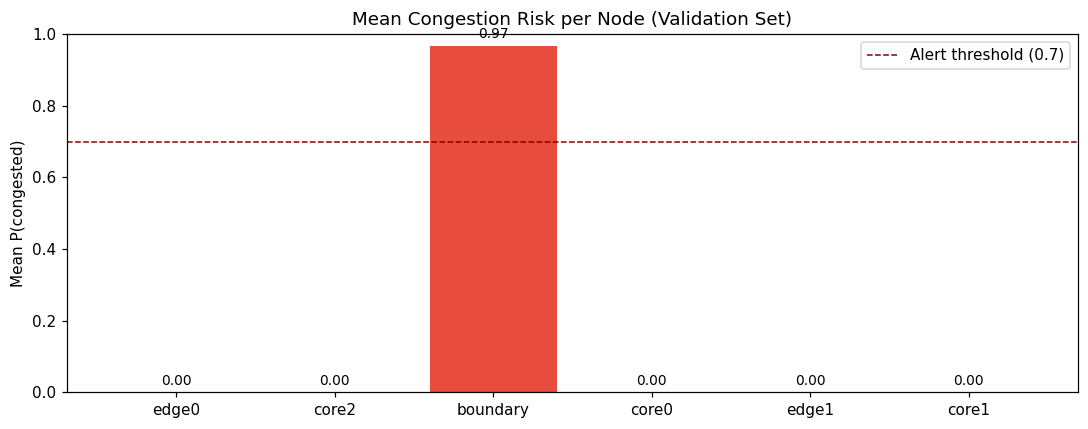


Red = high risk (>0.5) | Orange = moderate (0.2–0.5) | Green = low (<0.2)


In [49]:
# ── Visualize per-node risk ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if r > 0.5 else '#f39c12' if r > 0.2 else '#2ecc71'
          for r in summary_df['congestion_risk_mean']]

bars = ax.bar(summary_df['node_id'], summary_df['congestion_risk_mean'], color=colors)
ax.axhline(CONGESTION_RISK_THRESHOLD, ls='--', color='darkred', lw=1, label=f'Alert threshold ({CONGESTION_RISK_THRESHOLD})')
ax.set_title('Mean Congestion Risk per Node (Validation Set)')
ax.set_ylabel('Mean P(congested)'); ax.set_ylim(0, 1); ax.legend()

for bar, val_r in zip(bars, summary_df['congestion_risk_mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val_r:.2f}', ha='center', fontsize=9)

plt.tight_layout(); plt.show()
print('\nRed = high risk (>0.5) | Orange = moderate (0.2–0.5) | Green = low (<0.2)')

---
## 18. Save Models & Outputs

In [178]:
import joblib

# Save XGBoost
xgb_model.save_model('xgb_congestion.json')
print('Saved: xgb_congestion.json')

# Save Isolation Forest + scaler
joblib.dump(iso_forest, 'isolation_forest.pkl')
joblib.dump(scaler,     'feature_scaler.pkl')
print('Saved: isolation_forest.pkl, feature_scaler.pkl')

# Save CNN
cnn_model.save('cnn_congestion.keras')
joblib.dump(seq_scaler, 'seq_scaler.pkl')
print('Saved: cnn_congestion.keras, seq_scaler.pkl')

# Save alert output
alerts_bnd.to_csv('alerts_boundary_val.csv', index=False)
summary_df.to_csv('node_alert_summary.csv', index=False)
print('Saved: alerts_boundary_val.csv, node_alert_summary.csv')

Saved: xgb_congestion.json
Saved: isolation_forest.pkl, feature_scaler.pkl
Saved: cnn_congestion.keras, seq_scaler.pkl
Saved: alerts_boundary_val.csv, node_alert_summary.csv


---
## Summary

### Window Size Decision
| Window | Nominal duration | Recommendation |
|---|---|---|
| W=5  | ~3s  | Too short — misses multi-step congestion build-up |
| **W=10** | **~5-6s** | **Recommended** — covers 1–2 congestion episodes, low noise |
| W=20 | ~12s | Useful for slow trend detection but all windows cross large gaps |
| W=60 | ~35s | Overkill — sequence is dominated by gap noise |

**Note:** Because the dataset has highly irregular time-steps (44% of gaps >5s), all window sizes face the same cross-gap contamination. W=10 minimizes contamination while maximizing temporal context.

### Model Roles
| Model | Role | Strength |
|---|---|---|
| **XGBoost** | Primary congestion classifier | Best accuracy, handles imbalance, fast inference |
| **Isolation Forest** | Anomaly scorer (congestion-side) | Unsupervised, no label needed, complements teammate's port-scan detector |
| **1D-CNN** | Temporal sequence forecaster | Captures local temporal patterns, handles irregular gaps via `t_diff` feature |

### Alert Pipeline
- **Congestion alert:** `P(label≥1) ≥ 0.70` from XGBoost
- **Anomaly alert:** IF anomaly score ≥ threshold (tune on validation)
- **Combined alert:** either fires → surfaces node + timestamp + severity for dashboard